# NB09d: Deep Learning Experiments for BDA (v31, with NB12 OOF predictions schema)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Collapsed from 87 to ~30 cells. All patches 64x64 at ~10m.

## Sections:
- S0: Config + DL paths
- S1: Imports + CUDA + Model + Loss
- S2: Data loading + GroupKFold split + Mask + Dataset class
- D1: xBD pretrain + eval
- D4: Building size sweep (20/50/100/200 m2 in one loop)
- D5: xBD transfer (zero-shot / finetune / joint)
- D8: Single-scene RGB experiments
- D9: Siamese pre/post RGB (6ch concatenation)
- D10: Modality ablation
- D11: Architecture comparison (SE-ResNeXt + scSE)
- D12: Results summary + save

**Note:** BRIGHT dataset was evaluated but dropped from experiments.
BRIGHT provides only post-event SAR from X-band sensors (COSMO-SkyMed, TerraSAR-X).
Cross-modal transfer from X-band to Sentinel-1 C-band is scientifically indefensible
(different wavelength, different scattering behaviour, different speckle characteristics).
Data retained in data_stack/BRIGHT_64 for future reference only.

# CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB09d CONFIG
# ---- shared ----
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
CITY = None # DL experiments start single-city

# ---- Load global_setup.py ----
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-06-21 23:26:17
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     933.2/7452.0 GB (6518.8 GB free)
  GDrive (F:)     1405.0/3726.0 GB (2321.0 GB free)
  Local data      11565.1/14901.9 GB (3336.8 GB free)
  Data stack      1405.0/3726.0 GB (2321.0 GB free)
  WSL ext4        69.0/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# S0: CONFIG + DL PATHS

In [2]:
# @title CELL S0: DL PATHS + PATCH CONFIG
# =============================================================================
# DL-specific paths derived from global_setup.
# All paths come from global_setup.py -- no hardcoded J: or /content/ paths.
# =============================================================================
from pathlib import Path
import sys

print("=" * 70)
print("CELL S0: DL PATHS + PATCH CONFIG")
print("=" * 70)

# data_stack paths (from global_setup)
CITY_DIR = STACK_DIR / CITY
BUILDINGS_GEOJSON = CITY_DIR / "buildings_overture_with_damage.geojson"

# Patch dirs from global_setup.py:
#   PATCH_DIR_MS   = BDA_PATCH_ROOT / "patches_ms_64" / CITY
#   PATCH_DIR_CARD = BDA_PATCH_ROOT / "patches_card_64" / CITY
#   PATCH_DIR      = PATCH_DIR_MS (default)
#   BDA_MASK_BASE_DIR = BDA_PATCH_ROOT / "masks"
#   SS_PRE_DIR, SS_POST_DIR, SS_MASK_DIR, SS_INDEX_PATH

# NOTE: SS_* single-scene paths removed. All MS patches in PATCH_DIR_MS
# are already single-scene (from NB03e P7), not median composites.
# D8 experiments use ACTIVE_PATCH_DIR with post_only=True.

# xBD/BRIGHT: use STACK_ROOT copies (from NB05a copy cell), NOT DATA_ROOT
XBD_DL_ROOT = STACK_DIR / "xBD_64"  # in data_stack (portable)
# If not there, try DATASET_ROOT
if not XBD_DL_ROOT.exists():
    XBD_DL_ROOT = DATASET_ROOT / "xBD_64" if "DATASET_ROOT" in dir() else XBD_DL_ROOT
# BRIGHT dropped: X-band SAR, cross-modal transfer to C-band indefensible
print(f"  XBD_DL_ROOT:       {XBD_DL_ROOT}")

# DL output
OUTPUT_ROOT = CONTENT_LOCAL / 'nb09d_dl_experiments'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
for d in ['models', 'plots', 'results', 'checkpoints']:
    (OUTPUT_ROOT / d).mkdir(exist_ok=True)

# DL hyperparams
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
ENCODER_NAME = "resnet34"
ENCODER_WEIGHTS = "imagenet"
PATCH_SIZE = 64
NUM_CLASSES = 1  # binary segmentation
MIN_BUILDING_AREA = 20  # m2, minimum building size for patches

print(f"\n  CITY:           {CITY}")
print(f"  STACK_DIR:      {STACK_DIR}")
print(f"  PATCH_DIR_MS:   {PATCH_DIR_MS}")
print(f"  PATCH_DIR_CARD: {PATCH_DIR_CARD}")
print(f"  OUTPUT_ROOT:    {OUTPUT_ROOT}")
print(f"  Patch size:     {PATCH_SIZE}x{PATCH_SIZE}")
TARGET_COL = 'damage_binary'

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
import numpy as _np_oof
import pandas as _pd_oof
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09d_{CITY}_{TIER_SELECTION}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = (OUTPUT_ROOT / 'oof_predictions')
OOF_DIR.mkdir(parents=True, exist_ok=True)

def save_oof_from_result(res, model_id, variant_id='',
                         is_final=False, threshold=0.5):
    '''Canonical OOF from a result dict (y_true, y_proba, groups,
       building_id, fold_id all same length).'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'building_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys")
        return None
    y_proba = _np_oof.asarray(res['y_proba'])
    yt = _np_oof.asarray(res['y_true']).astype(int)
    fold = _np_oof.asarray(res['fold_id']).astype(int)
    bid = _np_oof.asarray(res['building_id'])
    cty = _np_oof.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = _np_oof.where(yt == 1,
                             _np_oof.where(yp == 1, 'TP', 'FN'),
                             _np_oof.where(yp == 1, 'FP', 'TN'))
    oof_df = _pd_oof.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

XBD_IMG_SIZE = 64
NUM_EPOCHS_BDA = 100
NUM_EPOCHS_XBD = 50
NUM_EPOCHS_FINETUNE = 50
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 15
NUM_WORKERS = 0  # drvfs is slow with multiprocess
DEVICE = "cuda"
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
RESULTS_ALL = {}
FORCE_RERUN_BDA_MASKS = False
FORCE_RERUN_TRAINING = False

RESULTS_DIR = OUTPUT_ROOT / 'results'
MODEL_DIR = OUTPUT_ROOT / 'models'
PLOTS_DIR = OUTPUT_ROOT / 'plots'

print(f"  Encoder:    {ENCODER_NAME} ({ENCODER_WEIGHTS})")
print(f"  TARGET_COL: {TARGET_COL}")
print(f"  Epochs:     {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")

# verify key paths
for name, path in [
    ("STACK_DIR", STACK_DIR),
    ("PATCH_DIR_MS", PATCH_DIR_MS),
    ("PATCH_DIR_CARD", PATCH_DIR_CARD),
    ("XBD_DL_ROOT", XBD_DL_ROOT),
]:
    exists = path.exists()
    print(f"  {name:20s}: {'OK' if exists else 'MISSING'}")


# ---- RESULT REGISTRY (for NB13 consolidation) ----
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09d')

def log_dl(exp_name, auc, cell_id='', note='', tags=None, extra=None):
    metrics = {'auc': float(auc)} if auc is not None else {}
    if extra and isinstance(extra, dict):
        metrics.update({k: v for k, v in extra.items() if isinstance(v, (int, float))})
    registry.log_experiment(
        cell_id=cell_id, experiment_name=exp_name,
        parquet_name='pixel_segmentation',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='U-Net',
        classifier_params={'encoder': ENCODER_NAME, 'patch_size': PATCH_SIZE,
                           'epochs_bda': NUM_EPOCHS_BDA, 'batch_size': BATCH_SIZE},
        feature_set_name='patches_64x64',
        cv_method='GroupKFold', imputation='nan_to_zero',
        metrics=metrics, note=note, tags=tags or [],
        extra=extra or {},
    )

# ---- SAVE HELPERS ----
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_DIR  # already created above

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        import json as _j
        with open(path, 'w') as fh:
            _j.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.name} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.name}")
    return path

print(f"  Helpers: save_result(), save_fig(), RESULTS_ALL")


CELL S0: DL PATHS + PATCH CONFIG
  XBD_DL_ROOT:       /mnt/f/PROJECTS/masterthesis/data_stack/xBD_64

  CITY:           Avdiivka
  STACK_DIR:      /mnt/f/PROJECTS/masterthesis/data_stack
  PATCH_DIR_MS:   /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Avdiivka
  PATCH_DIR_CARD: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_card_64/Avdiivka
  OUTPUT_ROOT:    /content/masterthesis_local/nb09d_dl_experiments
  Patch size:     64x64
  EXPERIMENT_ID: 20260621_232730_213609
  Encoder:    resnet34 (imagenet)
  TARGET_COL: damage_binary
  Epochs:     30, Batch: 16, LR: 0.0001
  STACK_DIR           : OK
  PATCH_DIR_MS        : OK
  PATCH_DIR_CARD      : OK
  XBD_DL_ROOT         : OK
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260621_232730)
  Helpers: save_result(), save_fig(), RESULTS_ALL


In [3]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
# NOTE: df_all is loaded in Cell 1a; these helpers use it at call time (late binding).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    # late-bind df_all (loaded in Cell 1a)
    bdf = buildings_df if buildings_df is not None else globals().get('df_all')
    if bdf is None:
        print("  plot_cm_spatial: no buildings df available (run Cell 1a first)")
        return None
    if 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no centroid_x/centroid_y in buildings_df")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUTPUT_ROOT / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# S1: IMPORTS + CUDA + MODEL

In [4]:
# @title CELL 0b: IMPORTS
import json, time, gc, shutil
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime
from pathlib import Path
from PIL import Image
from shapely.geometry import shape, box
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
print(f"torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}, smp: {smp.__version__}")
print("Imports OK")


# @title CELL 0b2: CUDA CHECK
CELL_ID = "cell_0b2_cuda_check"
print("=" * 70)
print("CELL 0b2: CUDA CHECK")
print("=" * 70)

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"Device count: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nDevice {i}: {props.name}")
        print(f"  Compute capability: {props.major}.{props.minor}")
        print(f"  Total memory: {props.total_memory / 1024**3:.1f} GB")
        print(f"  Multi-processors: {props.multi_processor_count}")
    
    print("\nTesting GPU tensor operation...")
    x = torch.randn(1000, 1000, device='cuda')
    y = torch.matmul(x, x)
    torch.cuda.synchronize()
    print(f"  Matrix multiply test: OK")
    print(f"  Current memory allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    del x, y
    torch.cuda.empty_cache()
    
    DEVICE = "cuda"
else:
    print("\nWARNING: CUDA not available, using CPU")
    DEVICE = "cpu"

print(f"\nUsing device: {DEVICE}")

torch: 2.10.0+cu128, CUDA: True, smp: 0.5.0
Imports OK
CELL 0b2: CUDA CHECK
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
Device count: 1

Device 0: NVIDIA GeForce RTX 2070 SUPER
  Compute capability: 7.5
  Total memory: 8.0 GB
  Multi-processors: 40

Testing GPU tensor operation...
  Matrix multiply test: OK
  Current memory allocated: 15.8 MB

Using device: cuda


# S2: MODEL + LOSS + TRAINING FUNCTIONS

In [5]:
# @title CELL 0d: MODEL, LOSS, TRAINING FUNCTIONS

def create_unet(in_channels=3, encoder_name='resnet34', encoder_weights='imagenet'):
    if in_channels != 3:
        encoder_weights = None
    return smp.Unet(encoder_name=encoder_name, encoder_weights=encoder_weights,
                    in_channels=in_channels, classes=1, activation=None)

class MaskedBCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, logits, targets, weights):
        bce_loss = (self.bce(logits, targets) * weights).sum() / (weights.sum() + 1e-8)
        probs = torch.sigmoid(logits)
        intersection = (probs * weights * targets * weights).sum()
        union = (probs * weights).sum() + (targets * weights).sum()
        dice_loss = 1 - (2 * intersection + 1e-8) / (union + 1e-8)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

criterion = MaskedBCEDiceLoss()

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0, 0
    for images, targets, weights in loader:
        images = torch.nan_to_num(images.to(device), nan=0.0)
        targets, weights = targets.to(device), weights.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), targets, weights)
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); n += 1
    return total_loss / max(n, 1)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0, 0
    all_p, all_t, all_w = [], [], []
    if len(loader) == 0: return 0.0, 0.5
    with torch.no_grad():
        for images, targets, weights in loader:
            images = torch.nan_to_num(images.to(device), nan=0.0)
            targets, weights = targets.to(device), weights.to(device)
            out = model(images)
            total_loss += criterion(out, targets, weights).item(); n += 1
            all_p.append(torch.sigmoid(out).cpu().numpy())
            all_t.append(targets.cpu().numpy())
            all_w.append(weights.cpu().numpy())
    pf = np.concatenate([x.flatten() for x in all_p])
    tf = np.concatenate([x.flatten() for x in all_t])
    wf = np.concatenate([x.flatten() for x in all_w])
    v = (wf > 0) & np.isfinite(pf) & np.isfinite(tf)
    auc = roc_auc_score(tf[v], pf[v]) if v.sum() > 0 and len(np.unique(tf[v])) > 1 else 0.5
    return total_loss / max(n, 1), auc

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                num_epochs, device, model_path, patience=15):
    best_auc, no_improve = 0, 0
    history = {'train_loss': [], 'test_loss': [], 'test_auc': []}
    for epoch in range(num_epochs):
        t0 = time.time()
        tl = train_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = eval_epoch(model, test_loader, criterion, device)
        scheduler.step(vl)
        history['train_loss'].append(float(tl))
        history['test_loss'].append(float(vl))
        history['test_auc'].append(float(va))
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {tl:.4f} | Test: {vl:.4f} | AUC: {va:.4f} | LR: {lr:.1e} | {time.time()-t0:.1f}s")
        if va > best_auc:
            best_auc = va; no_improve = 0
            torch.save(model.state_dict(), model_path)
            print(f"  -> Saved (AUC={best_auc:.4f})")
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}"); break
    print(f"Best test AUC: {best_auc:.4f}")
    return history, best_auc

def plot_history(history, exp_name):
    """Plot training loss + AUC curves. Display in notebook + save to disk."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='train')
    ax1.plot(epochs, history['test_loss'], label='test')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title(f'{exp_name}: Loss')
    ax1.legend()
    ax2.plot(epochs, history['test_auc'], label='test AUC', color='green')
    ax2.axhline(max(history['test_auc']), color='red', linestyle='--', alpha=0.5,
                label=f'best={max(history["test_auc"]):.3f}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.set_title(f'{exp_name}: AUC')
    ax2.legend()
    save_fig(fig, f'{exp_name}_curves', 'training_curves')
    return fig

def extract_unet_oof(model, ds_test, device, model_id, variant_id=''):
    '''Extract per-building OOF predictions from trained U-Net on test set.

    Aggregates pixel probabilities over the building footprint (weight > 0 pixels in
    the target mask) using mean pooling, producing one scalar probability per building.
    This maps the pixel-level U-Net output to a canonical per-building OOF parquet
    compatible with the NB12 overlap analysis.

    Assumes ds_test is a BDADataset (has .samples list of tuples where element [1]
    is the pp_post file path). Silently skips if ds_test doesn't match.
    '''
    # duck-type check: only BDADataset has the (pp_pre, pp_post, mp, ...) sample format
    if not hasattr(ds_test, 'samples') or len(ds_test.samples) == 0:
        print(f"    extract_unet_oof: skipped {model_id}: no samples")
        return None
    first = ds_test.samples[0]
    if not isinstance(first, tuple) or len(first) < 3 or not str(first[1]).endswith('_post.tif'):
        print(f"    extract_unet_oof: skipped {model_id}: ds_test not a BDADataset")
        return None

    # build id->city / id->label lookups from df_all (module-level, set in Cell 1a)
    df_all_local = globals().get('df_all')
    if df_all_local is None:
        print(f"    extract_unet_oof: skipped {model_id}: df_all not in scope")
        return None
    bid_to_city = dict(zip(df_all_local['building_id'],
                            df_all_local['city'] if 'city' in df_all_local.columns
                            else [CITY] * len(df_all_local)))
    bid_to_label = dict(zip(df_all_local['building_id'], df_all_local[TARGET_COL]))

    model.eval()
    building_ids, cities, y_true, y_proba, fold_ids = [], [], [], [], []
    with torch.no_grad():
        for i in range(len(ds_test)):
            pp_post = ds_test.samples[i][1]
            bid = pp_post.stem.replace('_post', '')
            try:
                img, target, weight = ds_test[i]
            except Exception as e:
                continue
            img_b = img.unsqueeze(0).to(device)
            img_b = torch.nan_to_num(img_b, nan=0.0)
            logits = model(img_b)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # [H, W]
            w_np = weight[0].cpu().numpy()                    # [H, W]
            bld_mask = w_np > 0
            if bld_mask.sum() == 0:
                continue
            proba_mean = float(prob[bld_mask].mean())
            yt = int(bid_to_label.get(bid, 0))
            city = bid_to_city.get(bid, CITY)
            building_ids.append(bid)
            cities.append(city)
            y_true.append(yt)
            y_proba.append(proba_mean)
            fold_ids.append(0)

    if not building_ids:
        print(f"    extract_unet_oof: no valid patches for {model_id}")
        return None

    res = {
        'building_id': np.array(building_ids),
        'groups':      np.array(cities),
        'y_true':      np.array(y_true),
        'y_proba':     np.array(y_proba),
        'fold_id':     np.array(fold_ids),
    }
    return save_oof_from_result(res, model_id,
                                 variant_id=variant_id or f'unet_pixel_aggregated;agg=mean_over_footprint')


def run_experiment(exp_name, model, train_loader, test_loader, num_epochs,
                   lr=None, patience=None, model_path=None):
    """Standard experiment runner: train, plot, store in RESULTS_ALL, save."""
    if lr is None: lr = LEARNING_RATE
    if patience is None: patience = EARLY_STOP_PATIENCE
    if model_path is None: model_path = MODEL_DIR / f'{exp_name}.pt'
    history_path = RESULTS_DIR / f'{exp_name}_history.json'

    if model_path.exists() and not FORCE_RERUN_TRAINING:
        print(f'  Model exists: {model_path.name}')
        if history_path.exists():
            with open(history_path) as f:
                h = json.load(f)
            best_auc = max(h['test_auc'])
            print(f'  Best AUC: {best_auc:.4f}')
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best_auc}
            log_dl(exp_name, best_auc, cell_id='run_experiment',
                   note=f'{exp_name}: loaded from cache', tags=['dl', exp_name, 'cached'])
            # NB12 OOF: reload best weights + extract per-building predictions
            try:
                model = model.to(DEVICE)
                model.load_state_dict(torch.load(model_path, map_location=DEVICE))
                ds_test = test_loader.dataset if test_loader is not None else None
                if ds_test is not None:
                    extract_unet_oof(model, ds_test, DEVICE, exp_name,
                                     variant_id=f'unet;exp={exp_name};cached')
                del model; gc.collect()
                if torch.cuda.is_available(): torch.cuda.empty_cache()
            except Exception as e:
                print(f'  OOF extract skipped (cache): {e}')
        return None, None

    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    h, best_auc = train_model(model, train_loader, test_loader, criterion,
                               optimizer, scheduler, num_epochs, DEVICE, model_path, patience)
    with open(history_path, 'w') as f:
        json.dump(h, f, indent=2)
    plot_history(h, exp_name)
    RESULTS_ALL[exp_name] = {'auc': best_auc}
    log_dl(exp_name, best_auc, cell_id='run_experiment',
           note=f'{exp_name}: {len(h["train_loss"])} epochs', tags=['dl', exp_name])
    save_result(pd.DataFrame([{'experiment': exp_name, 'best_auc': best_auc,
                                'epochs': len(h['train_loss'])}]),
                f'{exp_name}_result', 'experiments')
    # NB12 OOF: reload best weights (train_model saved them to model_path on best AUC)
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        ds_test = test_loader.dataset if test_loader is not None else None
        if ds_test is not None:
            extract_unet_oof(model, ds_test, DEVICE, exp_name,
                             variant_id=f'unet;exp={exp_name}')
    except Exception as e:
        print(f'  OOF extract skipped: {e}')
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return h, best_auc

def get_bda_loaders(channels=None, post_only=False):
    """Create BDA train/test DataLoaders from shared variables."""
    if channels is None:
        channels = CHANNEL_GROUPS.get('ms_post_rgb', list(range(3)))
    ds_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', channels, PATCH_SPLIT, 1, post_only=post_only)
    ds_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', channels, PATCH_SPLIT, 1, post_only=post_only)
    if len(ds_train) == 0 or len(ds_test) == 0:
        return None, None
    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return dl_train, dl_test

def create_fusion_unet_from_xbd(xbd_weights_path, in_channels, rgb_indices,
                                encoder_name='resnet34', first_conv_key='encoder.conv1.weight'):
    """Create a U-Net with N channels and initialize it from an xBD-pretrained 3ch model.

    RGB channel indices (in the new in_channels stack) receive the xBD first-conv weights
    (duplicated per group of 3 if len(rgb_indices) > 3). Non-RGB channels keep their
    default Kaiming init. Rest of the encoder + decoder gets xBD weights verbatim.

    Args:
        xbd_weights_path: Path to xBD-pretrained state_dict (3ch U-Net).
        in_channels: Target input channels (e.g. 10 for fusion_prepost, 5 for fusion_post).
        rgb_indices: List of channel indices in the NEW input that correspond to RGB.
                     Length must be a multiple of 3. Each group of 3 gets xBD weights.
                     fusion_prepost 10ch: [0,1,2,3,4,5]  (RGB_pre + RGB_post)
                     fusion_post    5ch:  [0,1,2]        (RGB_post only)
        encoder_name: smp encoder name (default resnet34).
        first_conv_key: state_dict key of the first conv layer.
    """
    if len(rgb_indices) == 0 or len(rgb_indices) % 3 != 0:
        raise ValueError(f"rgb_indices must be non-empty multiple of 3, got {rgb_indices}")
    model = smp.Unet(encoder_name=encoder_name, encoder_weights=None,
                     in_channels=in_channels, classes=1, activation=None)
    xbd_sd = torch.load(xbd_weights_path, map_location='cpu')
    tgt_sd = model.state_dict()
    n_copied, n_shape_mismatch = 0, 0
    for k, v in xbd_sd.items():
        if k not in tgt_sd:
            continue
        if tgt_sd[k].shape == v.shape:
            tgt_sd[k] = v.clone()
            n_copied += 1
        else:
            n_shape_mismatch += 1
    # first conv surgery: copy xBD RGB weights into rgb_indices slots (random for rest)
    if first_conv_key in xbd_sd and first_conv_key in tgt_sd:
        xbd_w = xbd_sd[first_conv_key]                    # [out, 3, k, k]
        tgt_w = model.state_dict()[first_conv_key].clone() # [out, in_channels, k, k] random
        for chunk_start in range(0, len(rgb_indices), 3):
            chunk = rgb_indices[chunk_start:chunk_start + 3]
            for j, tgt_idx in enumerate(chunk):
                if tgt_idx < in_channels:
                    tgt_w[:, tgt_idx] = xbd_w[:, j]
        tgt_sd[first_conv_key] = tgt_w
    model.load_state_dict(tgt_sd, strict=True)
    print(f"  fusion init: copied {n_copied} tensors from xBD, "
          f"{n_shape_mismatch} shape mismatch (first conv surgery on rgb_indices={rgb_indices})")
    return model


print("Functions: create_unet, create_fusion_unet_from_xbd, train_model, eval_epoch, plot_history, run_experiment, get_bda_loaders, extract_unet_oof")


Functions: create_unet, create_fusion_unet_from_xbd, train_model, eval_epoch, plot_history, run_experiment, get_bda_loaders, extract_unet_oof


# S3: LOAD DATASET + PATCHES

In [6]:
# @title CELL 1a: LOAD DATASET + PATCH INDEX
print("=" * 70)
print("CELL 1a: LOAD DATASET + PATCH INDEX")
print("=" * 70)

# --- building metadata (labels, area) from buildings geojson ---
_bldg_gj = STACK_DIR / CITY / "buildings_overture_with_damage.geojson"
if _bldg_gj.exists():
    _gdf = gpd.read_file(_bldg_gj)
    _gdf['building_id'] = [f"{CITY}_{i}" for i in range(len(_gdf))]
    if 'damage_binary' not in _gdf.columns:
        if 'unosat_damage_level' in _gdf.columns:
            _gdf['damage_binary'] = (_gdf['unosat_damage_level'].isin(['Severe Damage', 'Destroyed'])).astype(int)
        else:
            _gdf['damage_binary'] = 0
    if 'area_m2' not in _gdf.columns:
        _gdf_utm = _gdf.to_crs(_gdf.estimate_utm_crs())
        _gdf['area_m2'] = _gdf_utm.geometry.area
    df_all = pd.DataFrame({
        'building_id': _gdf['building_id'],
        TARGET_COL: pd.to_numeric(_gdf['damage_binary'], errors='coerce').fillna(0).astype(int),
        'area_m2': _gdf['area_m2'],
        'city': CITY,
    })
    print(f"Buildings from geojson: {len(df_all)}")
else:
    # fallback: try parquet
    _pq = STACK_DIR / CITY / "bda_buildings.parquet"
    if _pq.exists():
        df_all = pd.read_parquet(_pq)
        if 'city' not in df_all.columns:
            df_all['city'] = CITY
        print(f"Buildings from parquet: {len(df_all)}")
    else:
        raise FileNotFoundError(f"No building data found for {CITY}:\n  {_bldg_gj}\n  {_pq}")

df_all[TARGET_COL] = pd.to_numeric(df_all[TARGET_COL], errors='coerce').fillna(0).astype(int)
n_dmg = (df_all[TARGET_COL] == 1).sum()
print(f"Buildings: {len(df_all)} ({n_dmg} damaged, {(df_all[TARGET_COL]==0).sum()} undamaged)")

# --- scan patch dirs for available patches ---
def scan_patch_dir(patch_dir):
    if not patch_dir.exists():
        return pd.DataFrame(columns=['building_id', 'city'])
    post_files = sorted(patch_dir.glob("*_post.tif"))
    bids = []
    for f in post_files:
        bid = f.stem.replace("_post", "")
        pre_f = patch_dir / f"{bid}_pre.tif"
        if pre_f.exists():
            bids.append(bid)
    city_name = patch_dir.name
    return pd.DataFrame({'building_id': bids, 'city': city_name})

df_patches_ms = scan_patch_dir(PATCH_DIR_MS)
df_patches_card = scan_patch_dir(PATCH_DIR_CARD)
print(f"MS patches:   {len(df_patches_ms)} with pre+post pairs in {PATCH_DIR_MS}")
print(f"CARD patches: {len(df_patches_card)} with pre+post pairs in {PATCH_DIR_CARD}")

# default: use MS if available, else CARD
if len(df_patches_ms) > 0:
    df_patches = df_patches_ms
    ACTIVE_PATCH_DIR = PATCH_DIR_MS
    ACTIVE_MODALITY = 'ms'
    IN_CHANNELS = 6  # 3 pre + 3 post RGB
    print(f"Active modality: MS ({IN_CHANNELS}ch = 3 pre + 3 post)")
elif len(df_patches_card) > 0:
    df_patches = df_patches_card
    ACTIVE_PATCH_DIR = PATCH_DIR_CARD
    ACTIVE_MODALITY = 'card'
    IN_CHANNELS = 4  # 2 pre + 2 post VV+VH
    print(f"Active modality: CARD ({IN_CHANNELS}ch = 2 pre + 2 post)")
else:
    raise FileNotFoundError(f"No patches found in {PATCH_DIR_MS} or {PATCH_DIR_CARD}")

MASK_DIR = BDA_MASK_BASE_DIR / ACTIVE_MODALITY / CITY
print(f"Mask dir: {MASK_DIR}")
print(f"Patches: {len(df_patches)} grid cells")

# ---- backward-compat aliases for downstream experiment cells ----
MASK_DIRS = {20: MASK_DIR, 50: MASK_DIR, 100: MASK_DIR, 200: MASK_DIR}
# channel indices in the pre+post stack
# MS 6ch stack: [pre_B04, pre_B03, pre_B02, post_B04, post_B03, post_B02]
# CARD 4ch stack: [pre_VV, pre_VH, post_VV, post_VH]
CHANNEL_GROUPS = {}
if len(df_patches_ms) > 0:
    CHANNEL_GROUPS['ms_pre_rgb']  = [0, 1, 2]
    CHANNEL_GROUPS['ms_post_rgb'] = [3, 4, 5]
    CHANNEL_GROUPS['ms_prepost']  = list(range(6))
if len(df_patches_card) > 0:
    CHANNEL_GROUPS['card_pre']     = [0, 1]
    CHANNEL_GROUPS['card_post']    = [2, 3]
    CHANNEL_GROUPS['card_prepost'] = list(range(4))
# fusion: MS+CARD. Fusion stacks are built by the dataset loader (cell 15).
#   fusion pre+post (10ch): [RGB_pre(3) + RGB_post(3) + CARD_pre(2) + CARD_post(2)]
#   fusion post-only (5ch): [RGB_post(3)           + CARD_post(2)]
FUSION_AVAILABLE = (len(df_patches_ms) > 0 and len(df_patches_card) > 0)
if FUSION_AVAILABLE:
    CHANNEL_GROUPS['fusion_prepost'] = list(range(10))
    CHANNEL_GROUPS['fusion_post']    = list(range(5))
# 'all' still points to the active modality's full stack (back-compat for D4 sweep etc.)
CHANNEL_GROUPS['all'] = list(range(IN_CHANNELS))
SELECTED_CHANNELS = CHANNEL_GROUPS.get('all', list(range(IN_CHANNELS)))
CHANNEL_CONFIG = ACTIVE_MODALITY
print(f"Compat aliases: MASK_DIRS, CHANNEL_GROUPS, SELECTED_CHANNELS set")
print(f"CHANNEL_GROUPS keys: {sorted(CHANNEL_GROUPS.keys())}")

# ---- per-modality mask dirs (masks are grid-aligned so interchangeable, but keep separate) ----
MASK_DIR_MS   = BDA_MASK_BASE_DIR / 'ms'   / CITY
MASK_DIR_CARD = BDA_MASK_BASE_DIR / 'card' / CITY

# ---- df_patches_both: buildings with patches in BOTH MS and CARD (for fusion) ----
if FUSION_AVAILABLE:
    _bids_ms   = set(df_patches_ms['building_id'])
    _bids_card = set(df_patches_card['building_id'])
    _bids_both = sorted(_bids_ms & _bids_card)
    df_patches_both = pd.DataFrame({'building_id': _bids_both, 'city': CITY})
    print(f"Fusion patches: {len(df_patches_both)} buildings with both MS + CARD")
else:
    df_patches_both = pd.DataFrame(columns=['building_id', 'city'])

# ---- EXPERIMENT_CONFIGS: declarative sweep used by D10 modality ablation ----
# Each config fully specifies what BDADataset and create_unet need.
EXPERIMENT_CONFIGS = {}
if len(df_patches_ms) > 0:
    EXPERIMENT_CONFIGS['ms_post_rgb'] = dict(
        modality='ms', primary_patch_dir=PATCH_DIR_MS, card_patch_dir=None,
        mask_dir=MASK_DIR_MS, df_patches=df_patches_ms,
        post_only=True, channels=[0, 1, 2], in_channels=3, use_imagenet=True)
    EXPERIMENT_CONFIGS['ms_prepost'] = dict(
        modality='ms', primary_patch_dir=PATCH_DIR_MS, card_patch_dir=None,
        mask_dir=MASK_DIR_MS, df_patches=df_patches_ms,
        post_only=False, channels=None, in_channels=6, use_imagenet=False)
if len(df_patches_card) > 0:
    EXPERIMENT_CONFIGS['card_post'] = dict(
        modality='card', primary_patch_dir=PATCH_DIR_CARD, card_patch_dir=None,
        mask_dir=MASK_DIR_CARD, df_patches=df_patches_card,
        post_only=True, channels=[0, 1], in_channels=2, use_imagenet=False)
    EXPERIMENT_CONFIGS['card_prepost'] = dict(
        modality='card', primary_patch_dir=PATCH_DIR_CARD, card_patch_dir=None,
        mask_dir=MASK_DIR_CARD, df_patches=df_patches_card,
        post_only=False, channels=None, in_channels=4, use_imagenet=False)
if FUSION_AVAILABLE:
    EXPERIMENT_CONFIGS['fusion_post'] = dict(
        modality='fusion', primary_patch_dir=PATCH_DIR_MS, card_patch_dir=PATCH_DIR_CARD,
        mask_dir=MASK_DIR_MS, df_patches=df_patches_both,
        post_only=True, channels=None, in_channels=5, use_imagenet=False)
    EXPERIMENT_CONFIGS['fusion_prepost'] = dict(
        modality='fusion', primary_patch_dir=PATCH_DIR_MS, card_patch_dir=PATCH_DIR_CARD,
        mask_dir=MASK_DIR_MS, df_patches=df_patches_both,
        post_only=False, channels=None, in_channels=10, use_imagenet=False)
print(f"EXPERIMENT_CONFIGS: {list(EXPERIMENT_CONFIGS.keys())}")

# ---- diagnostic: sample patch stats so user can pick normalize_range per modality ----
def _sample_patch_stats(patch_dir, label):
    files = sorted(patch_dir.glob('*_post.tif'))
    if not files:
        print(f"  {label}: no patches")
        return
    with rasterio.open(files[0]) as src:
        arr = src.read().astype(np.float32)
    for c in range(arr.shape[0]):
        v = arr[c]
        v = v[np.isfinite(v)]
        if len(v) > 0:
            print(f"  {label} ch{c}: min={v.min():.4f} max={v.max():.4f} "
                  f"mean={v.mean():.4f} std={v.std():.4f} (sample {files[0].name})")

print("\n  Sample patch statistics (first post-TIF per modality):")
if len(df_patches_ms) > 0:
    _sample_patch_stats(PATCH_DIR_MS, 'MS  ')
if len(df_patches_card) > 0:
    _sample_patch_stats(PATCH_DIR_CARD, 'CARD')

# ---- default normalize_range per modality (override in EXPERIMENT_CONFIGS if needed) ----
# MS: S2 L2A reflectance scaled by 10000 -> values ~[0, 10000] -> /10000 -> [0, 1]
# CARD: S1 gamma0. If LINEAR (most ARD products), values ~[0, 2] -> /1.0 -> mostly [0, 1]
#       If dB, values ~[-30, 0] -> this divisor will NOT work and you need per-scheme logic.
#       Inspect the printed CARD stats above:
#         - if mean is in [0, 1] range  -> linear, keep DEFAULT_CARD_NORM=1.0
#         - if mean is negative (-5..-20) -> dB, use a custom mapping (see iteration notes)
DEFAULT_MS_NORM = 10000.0
DEFAULT_CARD_NORM = 1.0  # linear gamma0 assumption; verify via the printed stats above

for _name, _c in EXPERIMENT_CONFIGS.items():
    if _c['modality'] == 'ms':
        _c.setdefault('normalize_range', DEFAULT_MS_NORM)
        _c.setdefault('card_normalize_range', None)
    elif _c['modality'] == 'card':
        _c.setdefault('normalize_range', DEFAULT_CARD_NORM)
        _c.setdefault('card_normalize_range', None)
    elif _c['modality'] == 'fusion':
        _c.setdefault('normalize_range', DEFAULT_MS_NORM)
        _c.setdefault('card_normalize_range', DEFAULT_CARD_NORM)
print(f"\n  Norm defaults: MS=/{DEFAULT_MS_NORM}, CARD=/{DEFAULT_CARD_NORM}"
      f" (per-config override via EXPERIMENT_CONFIGS[name]['normalize_range'])")


CELL 1a: LOAD DATASET + PATCH INDEX
Buildings from geojson: 13360
Buildings: 13360 (89 damaged, 12434 undamaged)
MS patches:   80 with pre+post pairs in /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Avdiivka
CARD patches: 80 with pre+post pairs in /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_card_64/Avdiivka
Active modality: MS (6ch = 3 pre + 3 post)
Mask dir: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/masks/ms/Avdiivka
Patches: 80 grid cells
Compat aliases: MASK_DIRS, CHANNEL_GROUPS, SELECTED_CHANNELS set
CHANNEL_GROUPS keys: ['all', 'card_post', 'card_pre', 'card_prepost', 'fusion_post', 'fusion_prepost', 'ms_post_rgb', 'ms_pre_rgb', 'ms_prepost']
Fusion patches: 80 buildings with both MS + CARD
EXPERIMENT_CONFIGS: ['ms_post_rgb', 'ms_prepost', 'card_post', 'card_prepost', 'fusion_post', 'fusion_prepost']

  Sample patch statistics (first post-TIF per modality):
  MS   ch0: min=1012.0000 max=2098.0000 mean=1

# S4: GROUPKFOLD SPLIT BY CITY

In [7]:
# @title CELL S4: PATCH SPLIT (GroupKFold by city)
from sklearn.model_selection import train_test_split
import numpy as np

if 'city' in df_patches.columns and df_patches['city'].nunique() > 1:
    cities = sorted(df_patches['city'].unique())
    np.random.seed(42)
    np.random.shuffle(cities)
    n_train = max(1, int(len(cities) * 0.65))
    n_test = max(1, int(len(cities) * 0.20))
    train_cities = cities[:n_train]
    test_cities = cities[n_train:n_train+n_test]
    val_cities = cities[n_train+n_test:]
    if not val_cities and len(test_cities) > 1:
        val_cities = [test_cities.pop()]

    PATCH_SPLIT = {}
    for _, row in df_patches.iterrows():
        bid = row['building_id']
        city = row['city']
        if city in train_cities: PATCH_SPLIT[bid] = 'train'
        elif city in test_cities: PATCH_SPLIT[bid] = 'test'
        else: PATCH_SPLIT[bid] = 'val'
    print(f"GroupKFold: train={len(train_cities)}c, test={len(test_cities)}c, val={len(val_cities)}c")
else:
    bids = df_patches['building_id'].tolist()
    # stratified split using damage labels
    labels = []
    dmg_map = df_all.set_index('building_id')[TARGET_COL].to_dict() if 'building_id' in df_all.columns else {}
    for bid in bids:
        labels.append(dmg_map.get(bid, 0))
    train_ids, temp_ids, train_lbl, temp_lbl = train_test_split(bids, labels, test_size=0.35, random_state=42, stratify=labels)
    test_ids, val_ids = train_test_split(temp_ids, test_size=0.43, random_state=42, stratify=temp_lbl)
    PATCH_SPLIT = {}
    for bid in train_ids: PATCH_SPLIT[bid] = 'train'
    for bid in test_ids: PATCH_SPLIT[bid] = 'test'
    for bid in val_ids: PATCH_SPLIT[bid] = 'val'
    n_tr = sum(1 for v in PATCH_SPLIT.values() if v == 'train')
    n_te = sum(1 for v in PATCH_SPLIT.values() if v == 'test')
    n_va = sum(1 for v in PATCH_SPLIT.values() if v == 'val')
    print(f"Single city -> stratified split: train={n_tr}, test={n_te}, val={n_va}")

print(f"Total patches: {len(PATCH_SPLIT)}")

Single city -> stratified split: train=52, test=15, val=13
Total patches: 80


# S5: MASK + DATASET CLASS

In [8]:
# @title CELL 1c: BDA MASK CREATION FUNCTION + DEFAULT MASKS
print("=" * 70)
print("CELL 1c: BDA MASK CREATION")
print("=" * 70)

# ---- load buildings for this city ----
print(f"Loading buildings from {BUILDINGS_GEOJSON}...")
gdf_buildings = gpd.read_file(BUILDINGS_GEOJSON)

# assign building_id matching NB05b convention: {city}_{row_index}
gdf_buildings['building_id'] = [f"{CITY}_{i}" for i in range(len(gdf_buildings))]

# map damage labels from buildings parquet
dmg_map = df_all.set_index('building_id')[TARGET_COL].to_dict() if 'building_id' in df_all.columns else {}
area_map = df_all.set_index('building_id')['area_m2'].to_dict() if 'building_id' in df_all.columns and 'area_m2' in df_all.columns else {}
gdf_buildings['damage_binary'] = pd.to_numeric(gdf_buildings['building_id'].map(dmg_map), errors='coerce').fillna(0).astype(int)
gdf_buildings['area_m2'] = gdf_buildings['building_id'].map(area_map)

# reproject to match patch CRS
ref_path = CITY_DIR / "reference_grid.json"
with open(ref_path) as f:
    ref_grid = json.load(f)
utm_epsg = ref_grid['utm_epsg']
ref_transform = Affine(*ref_grid['transform'][:6])

if gdf_buildings.crs is None:
    gdf_buildings = gdf_buildings.set_crs("EPSG:4326")
gdf_buildings_utm = gdf_buildings.to_crs(f"EPSG:{utm_epsg}")
print(f"Buildings loaded: {len(gdf_buildings_utm)} (UTM {utm_epsg})")

half = PATCH_SIZE // 2

def create_bda_masks_for_dir(patch_dir, mask_dir, min_area_m2=20):
    mask_dir = Path(mask_dir)
    mask_dir.mkdir(parents=True, exist_ok=True)

    gdf = gdf_buildings_utm[gdf_buildings_utm['area_m2'] >= min_area_m2].copy()
    sindex = gdf.sindex

    post_files = sorted(patch_dir.glob("*_post.tif"))
    existing = list(mask_dir.glob("*_mask.tif"))
    if len(existing) >= len(post_files) and not FORCE_RERUN_BDA_MASKS:
        print(f"  {mask_dir.name}: {len(existing)} masks exist, skipping")
        return

    if FORCE_RERUN_BDA_MASKS and existing:
        shutil.rmtree(mask_dir)
        mask_dir.mkdir(parents=True, exist_ok=True)

    print(f"  Creating masks for {len(post_files)} buildings (min_area={min_area_m2}m2, {len(gdf)} eligible)...")
    success, failed = 0, 0
    for post_f in post_files:
        bid = post_f.stem.replace("_post", "")
        out_path = mask_dir / f"{bid}_mask.tif"
        if out_path.exists():
            success += 1
            continue
        try:
            with rasterio.open(post_f) as src:
                win_transform = src.transform
                win_crs = src.crs

            # patch bounding box in UTM
            minx = win_transform.c
            maxy = win_transform.f
            maxx = minx + PATCH_SIZE * win_transform.a
            miny = maxy + PATCH_SIZE * win_transform.e
            patch_bbox = box(min(minx, maxx), min(miny, maxy), max(minx, maxx), max(miny, maxy))

            candidates = list(sindex.intersection(patch_bbox.bounds))
            bldgs = gdf.iloc[candidates]
            bldgs = bldgs[bldgs.geometry.intersects(patch_bbox)]

            # band 1: damage (0=undamaged, 1=damaged, 255=bg)
            band1 = np.full((PATCH_SIZE, PATCH_SIZE), 255, dtype=np.uint8)
            und = [(g, 0) for g, d in zip(bldgs.geometry, bldgs['damage_binary']) if d == 0]
            dam = [(g, 1) for g, d in zip(bldgs.geometry, bldgs['damage_binary']) if d == 1]
            if und:
                band1 = rasterize(und, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=255, dtype=np.uint8)
            if dam:
                dr = rasterize(dam, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=0, dtype=np.uint8)
                band1[dr == 1] = 1

            # band 2: weight (1=building pixel, 0=bg)
            band2 = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
            all_s = [(g, 1) for g in bldgs.geometry]
            if all_s:
                band2 = rasterize(all_s, out_shape=(PATCH_SIZE, PATCH_SIZE), transform=win_transform, fill=0, dtype=np.uint8)

            with rasterio.open(out_path, 'w', driver='GTiff', height=PATCH_SIZE, width=PATCH_SIZE,
                              count=2, dtype=np.uint8, crs=win_crs, transform=win_transform) as dst:
                dst.write(np.stack([band1, band2]))
            success += 1
        except Exception as e:
            failed += 1
            if failed <= 3:
                print(f"    FAIL {bid}: {e}")
    print(f"  Done: {success} created, {failed} failed")

# ---- create masks for the active modality ----
MASK_DIR = BDA_MASK_BASE_DIR / ACTIVE_MODALITY / CITY
create_bda_masks_for_dir(ACTIVE_PATCH_DIR, MASK_DIR, min_area_m2=MIN_BUILDING_AREA)
print(f"\nMask dir: {MASK_DIR}")

# ---- also create masks for the non-active modality (for D10 CARD/fusion configs) ----
if len(df_patches_ms) > 0 and MASK_DIR_MS != MASK_DIR:
    create_bda_masks_for_dir(PATCH_DIR_MS, MASK_DIR_MS, min_area_m2=MIN_BUILDING_AREA)
if len(df_patches_card) > 0 and MASK_DIR_CARD != MASK_DIR:
    create_bda_masks_for_dir(PATCH_DIR_CARD, MASK_DIR_CARD, min_area_m2=MIN_BUILDING_AREA)

CELL 1c: BDA MASK CREATION
Loading buildings from /mnt/f/PROJECTS/masterthesis/data_stack/Avdiivka/buildings_overture_with_damage.geojson...
Buildings loaded: 13360 (UTM 32637)
  Avdiivka: 80 masks exist, skipping

Mask dir: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/masks/ms/Avdiivka
  Avdiivka: 80 masks exist, skipping


In [9]:
# @title CELL 1d: BDA PYTORCH DATASET CLASS

class BDADataset(Dataset):
    """Load BDA pre/post patch pairs + masks.
    Concatenates pre+post along channel dim -> change signal for U-Net.
    post_only=True: load only post image (for xBD/BRIGHT zero-shot with 3ch model).
    patch_dir_card: if set, also loads CARD patches for the same building_id and
                    concatenates them after the primary (MS) patches. Fusion mode.
                    Pre+post stack (10ch): [RGB_pre(3) + RGB_post(3) + CARD_pre(2) + CARD_post(2)]
                    Post-only stack (5ch): [RGB_post(3)              + CARD_post(2)]
    channels: select channel indices from the concatenated (or post-only) image.
    normalize_range: divisor applied to MS section (default 10000 = S2 L2A reflectance).
    card_normalize_range: divisor applied to CARD section (default = normalize_range
                    for backward compat; set to ~1.0 for linear gamma0 or adjust
                    after inspecting CARD sample stats in Cell 1a).
    """
    def __init__(self, patch_dir, mask_dir, patch_index, split='train', channels=None,
                 patch_split_map=None, min_labeled_pixels=1, normalize_range=10000.0,
                 post_only=False, patch_dir_card=None, card_normalize_range=None):
        self.patch_dir = Path(patch_dir)
        self.patch_dir_card = Path(patch_dir_card) if patch_dir_card is not None else None
        self.fusion = self.patch_dir_card is not None
        self.mask_dir = Path(mask_dir)
        self.normalize_range = normalize_range
        self.card_normalize_range = card_normalize_range if card_normalize_range is not None else normalize_range
        self.channels = channels
        self.post_only = post_only
        self.samples = []
        for _, row in patch_index.iterrows():
            bid = row['building_id']
            if patch_split_map is not None and patch_split_map.get(bid) != split:
                continue
            pp_pre = self.patch_dir / f"{bid}_pre.tif"
            pp_post = self.patch_dir / f"{bid}_post.tif"
            mp = self.mask_dir / f"{bid}_mask.tif"
            if not pp_post.exists() or not mp.exists():
                continue
            if not post_only and not pp_pre.exists():
                continue
            cp_pre, cp_post = None, None
            if self.fusion:
                cp_pre = self.patch_dir_card / f"{bid}_pre.tif"
                cp_post = self.patch_dir_card / f"{bid}_post.tif"
                if not cp_post.exists():
                    continue
                if not post_only and not cp_pre.exists():
                    continue
            if min_labeled_pixels > 0:
                with rasterio.open(mp) as src:
                    m = src.read()
                if (m[1] == 1).sum() < min_labeled_pixels:
                    continue
            if self.fusion:
                self.samples.append((pp_pre, pp_post, mp, cp_pre, cp_post))
            else:
                self.samples.append((pp_pre, pp_post, mp))
        mode = 'fusion' if self.fusion else ('post_only' if post_only else 'pre+post')
        norm_note = f"norm=ms/{self.normalize_range}, card/{self.card_normalize_range}" if self.fusion else f"norm=/{self.normalize_range}"
        print(f"  {split}: {len(self.samples)} patches ({mode}, {norm_note})")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        if self.fusion:
            pp_pre, pp_post, mp, cp_pre, cp_post = self.samples[idx]
        else:
            pp_pre, pp_post, mp = self.samples[idx]
            cp_pre, cp_post = None, None
        # primary (MS) post
        with rasterio.open(pp_post) as src:
            post = src.read().astype(np.float32)
        if self.post_only:
            img = post
        else:
            with rasterio.open(pp_pre) as src:
                pre = src.read().astype(np.float32)
            img = np.concatenate([pre, post], axis=0)
        # remember where CARD begins (fusion split point) before appending CARD
        ms_ch = img.shape[0]
        # fusion: append CARD after MS
        if self.fusion:
            with rasterio.open(cp_post) as src:
                card_post = src.read().astype(np.float32)
            if self.post_only:
                img = np.concatenate([img, card_post], axis=0)
            else:
                with rasterio.open(cp_pre) as src:
                    card_pre = src.read().astype(np.float32)
                img = np.concatenate([img, card_pre, card_post], axis=0)
        # per-section normalization
        img = np.nan_to_num(img, nan=0.0)
        if self.fusion:
            img_ms = np.clip(img[:ms_ch] / self.normalize_range, 0, 1)
            img_card = np.clip(img[ms_ch:] / self.card_normalize_range, 0, 1)
            img = np.concatenate([img_ms, img_card], axis=0)
        else:
            img = np.clip(img / self.normalize_range, 0, 1)
        if self.channels is not None:
            img = img[self.channels]
        with rasterio.open(mp) as src:
            mask = src.read()
        target = np.where(mask[0] == 255, 0, mask[0]).astype(np.float32)
        weight = mask[1].astype(np.float32)
        return torch.from_numpy(img), torch.from_numpy(target).unsqueeze(0), torch.from_numpy(weight).unsqueeze(0)


class BDASegDataset(BDADataset):
    """Alias for experiment cells that use BDASegDataset name."""
    pass


print(f"BDADataset class ready (pre+post concat | post_only | channel select | fusion MS+CARD | per-modality norm)")


BDADataset class ready (pre+post concat | post_only | channel select | fusion MS+CARD | per-modality norm)


# D1: xBD PRETRAIN + EVAL

In [10]:
# @title CELL 2a: xBD MASK VERIFICATION
for split in ['train', 'val']:
    img_dir = XBD_DL_ROOT / split / 'images'
    mask_dir = XBD_DL_ROOT / split / 'labels'
    if not img_dir.exists(): print(f"  {split}: NOT FOUND"); continue
    ni = len(list(img_dir.glob("*_post_disaster.png")))
    nm = len(list(mask_dir.glob("*_post_disaster.png"))) if mask_dir.exists() else 0
    print(f"  {split}: {ni} images, {nm} masks [{'OK' if ni==nm else 'MISMATCH'}]")


  train: 4849 images, 4849 masks [OK]
  val: 1061 images, 1061 masks [OK]


In [11]:
# @title CELL 2b: xBD DATASET + PRETRAIN
print("=" * 70)
print("CELL 2b: xBD DATASET + PRETRAIN")
print("=" * 70)

class XBDDataset(Dataset):
    def __init__(self, xbd_root, split='train'):
        self.samples = []
        idir = Path(xbd_root) / split / 'images'
        mdir = Path(xbd_root) / split / 'labels'
        if idir.exists() and mdir.exists():
            for ip in sorted(idir.glob("*_post_disaster.png")):
                mp = mdir / ip.name
                if mp.exists(): self.samples.append((ip, mp))
        print(f"  xBD {split}: {len(self.samples)} pairs")
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        img = np.array(Image.open(ip))
        if img.ndim == 2: img = np.stack([img]*3, axis=-1)
        img = img[:,:,:3].transpose(2,0,1).astype(np.float32) / 255.0
        mask = np.array(Image.open(mp))
        target = np.where(mask >= 2, 1, np.where(mask == 1, 0, 0)).astype(np.float32)
        weight = (mask >= 1).astype(np.float32)
        return torch.from_numpy(img), torch.from_numpy(target).unsqueeze(0), torch.from_numpy(weight).unsqueeze(0)

xbd_train_dataset = XBDDataset(XBD_DL_ROOT, 'train')
xbd_val_dataset = XBDDataset(XBD_DL_ROOT, 'val')
xbd_pretrain_skip = len(xbd_train_dataset) == 0
xbd_pretrain_path = MODEL_DIR / "xbd_pretrained.pt"

if xbd_pretrain_skip:
    print("WARNING: No xBD data")
elif xbd_pretrain_path.exists() and not FORCE_RERUN_TRAINING:
    print(f"Model exists: {xbd_pretrain_path}")
else:
    m = create_unet(in_channels=3, encoder_name=ENCODER_NAME); m = m.to(DEVICE)
    o = optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
    tl = DataLoader(xbd_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    vl = DataLoader(xbd_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    h, best = train_model(m, tl, vl, criterion, o, s, NUM_EPOCHS_XBD, DEVICE, xbd_pretrain_path, EARLY_STOP_PATIENCE)
    with open(RESULTS_DIR / "xbd_pretrain_history.json", 'w') as f: json.dump(h, f, indent=2)
    plot_history(h, 'xbd_pretrain')
    RESULTS_ALL['d1_xbd_pretrain'] = {'auc': best}
    log_dl('d1_xbd_pretrain', best, cell_id='cell_2b',
           note='xBD pretraining', tags=['dl', 'xbd', 'pretrain'])
    del m; gc.collect(); torch.cuda.empty_cache()


CELL 2b: xBD DATASET + PRETRAIN
  xBD train: 4849 pairs
  xBD val: 1061 pairs
Model exists: /content/masterthesis_local/nb09d_dl_experiments/models/xbd_pretrained.pt


In [12]:
# @title CELL 2c: xBD EVAL ON xBD VAL
print("=" * 70)
print("CELL 2c: xBD EVAL ON xBD VAL")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif len(xbd_val_dataset) == 0:
    print("SKIP: No xBD val data")
else:
    m = create_unet(in_channels=3, encoder_weights=None)
    m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
    m = m.to(DEVICE)
    vl = DataLoader(xbd_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    loss, auc = eval_epoch(m, vl, criterion, DEVICE)
    print(f"xBD Val: Loss={loss:.4f}, AUC={auc:.4f}")
    RESULTS_ALL['xbd_on_xbd'] = {'auc': float(auc)}
    log_dl('xbd_on_xbd', float(auc), cell_id='cell_2c',
           note='xBD eval on xBD val (VALID reference)', tags=['dl', 'xbd', 'reference'])
    save_result(pd.DataFrame([{'experiment': 'xbd_on_xbd', 'auc': auc, 'loss': loss}]),
                'xbd_on_xbd', 'experiments')
    del m; gc.collect(); torch.cuda.empty_cache()


CELL 2c: xBD EVAL ON xBD VAL
xBD Val: Loss=0.3943, AUC=0.9643
  REG: xbd_on_xbd                                    AUC=0.9643 F1=? n=None feat=0 cities=0 [NB09d/cell_2c]
  Saved: xbd_on_xbd_20260621_232824.csv (0.1 KB)


# D2: BRIGHT — DROPPED

BRIGHT dropped: only post-event X-band SAR available (COSMO-SkyMed, TerraSAR-X).
Cross-modal transfer from X-band to Sentinel-1 C-band is scientifically indefensible.
Data retained in `data_stack/BRIGHT_64/` for future reference.


In [13]:
# BRIGHT DROPPED — see markdown cell above for rationale.
# Variables set to safe defaults so downstream cells don't crash.
bright_pretrain_skip = True
bright_pretrain_path = MODEL_DIR / "bright_pretrained.pt"
bright_train_dataset = []
bright_val_dataset = []
print("BRIGHT: SKIPPED (X-band SAR, cross-modal transfer indefensible)")


BRIGHT: SKIPPED (X-band SAR, cross-modal transfer indefensible)


In [14]:
# BRIGHT eval — DROPPED (see D2 rationale)


# D3: xBD + BRIGHT Combined — DROPPED

Combined pretraining removed: BRIGHT data incompatible (X-band vs C-band).


In [15]:
# xBD + BRIGHT combined pretrain — DROPPED (see D3 rationale)


# D4: BUILDING SIZE SWEEP (20/50/100/200 m2)

In [16]:
# @title CELL D4: BUILDING SIZE SWEEP
# Collapsed from 4 separate cells. Tests minimum building area thresholds.
# Patches 64x64. Mask: binary damage from buildings >= MIN_AREA.
print("=" * 70)
print("CELL D4: BUILDING SIZE SWEEP")
print("=" * 70)

# RESULTS_ALL defined in S0

for min_area in [20, 50, 100, 200]:
    print(f"\n  ===== MIN AREA = {min_area} m2 =====")

    # filter buildings by area
    if 'area_m2' in df_all.columns:
        df_filtered = df_all[df_all['area_m2'] >= min_area].copy()
    else:
        df_filtered = df_all.copy()
        print(f"  WARNING: area_m2 column not in df, using all buildings")

    # create filtered mask + dataset
    # (reuses create_masks / BDASegDataset from S5)
    train_patches = [p for p, s in PATCH_SPLIT.items() if s == 'train']
    test_patches = [p for p, s in PATCH_SPLIT.items() if s == 'test']
    val_patches = [p for p, s in PATCH_SPLIT.items() if s == 'val']

    # create area-filtered masks
    area_mask_dir = BDA_MASK_BASE_DIR / ACTIVE_MODALITY / CITY / f"area{min_area}"
    create_bda_masks_for_dir(ACTIVE_PATCH_DIR, area_mask_dir, min_area_m2=min_area)

    try:
        ds_train = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'train', SELECTED_CHANNELS, PATCH_SPLIT, 1)
        ds_test = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'test', SELECTED_CHANNELS, PATCH_SPLIT, 1)
        ds_val = BDADataset(ACTIVE_PATCH_DIR, area_mask_dir, df_patches, 'val', SELECTED_CHANNELS, PATCH_SPLIT, 1)

        dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        print(f"  Train: {len(ds_train)}, Test: {len(ds_test)}, Val: {len(ds_val)}")

        if len(ds_train) == 0 or len(ds_test) == 0:
            print(f"  SKIP: empty dataset for min_area={min_area}")
            continue

        model = create_unet(in_channels=IN_CHANNELS, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        best_val_loss = float('inf')
        for epoch in range(NUM_EPOCHS_BDA):
            train_loss = train_epoch(model, dl_train, criterion, optimizer, DEVICE)
            val_loss, val_auc = eval_epoch(model, dl_val, criterion, DEVICE)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
            if (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_auc={val_auc:.3f}")

        test_loss, test_auc = eval_epoch(model, dl_test, criterion, DEVICE)
        print(f"  RESULT: min_area={min_area} -> test_AUC={test_auc:.3f}")
        RESULTS_ALL[f'bda_min{min_area}'] = {'auc': test_auc, 'min_area': min_area,
                                              'n_train': len(ds_train), 'n_test': len(ds_test)}
        extract_unet_oof(model, ds_test, DEVICE, f'D4_bda_min{min_area}',
                         variant_id=f'unet_size_sweep;min_area_m2={min_area}')
    except Exception as e:
        print(f"  ERROR: {e}")

# summary
print(f"\n  SUMMARY:")
for k, v in sorted(RESULTS_ALL.items()):
    if 'n_train' in v:
        print(f"    {k}: AUC={v['auc']:.3f} (train={v['n_train']}, test={v['n_test']})")
    else:
        print(f"    {k}: AUC={v['auc']:.3f}")



CELL D4: BUILDING SIZE SWEEP

  ===== MIN AREA = 20 m2 =====
  area20: 80 masks exist, skipping
  train: 49 patches (pre+post, norm=/10000.0)
  test: 15 patches (pre+post, norm=/10000.0)
  val: 12 patches (pre+post, norm=/10000.0)
  Train: 49, Test: 15, Val: 12
    Epoch  10: train_loss=0.7364 val_loss=0.7347 val_auc=0.328
    Epoch  20: train_loss=0.5740 val_loss=0.7110 val_auc=0.341
    Epoch  30: train_loss=0.5778 val_loss=0.7041 val_auc=0.422
    Epoch  40: train_loss=0.4940 val_loss=0.6662 val_auc=0.423
    Epoch  50: train_loss=0.4491 val_loss=0.6589 val_auc=0.348
    Epoch  60: train_loss=0.3616 val_loss=0.6289 val_auc=0.436
    Epoch  70: train_loss=0.3227 val_loss=0.6301 val_auc=0.464
    Epoch  80: train_loss=0.2743 val_loss=0.6233 val_auc=0.462
    Epoch  90: train_loss=0.2162 val_loss=0.6036 val_auc=0.527
    Epoch 100: train_loss=0.1575 val_loss=0.6057 val_auc=0.488
  RESULT: min_area=20 -> test_AUC=0.436
    saved oof -> oof_D4_bda_min20__20260621_232730_213609.parquet  T

# D5: xBD TRANSFER (zero-shot / finetune / joint)

In [17]:
# @title CELL 4a: xBD ZERO-SHOT ON BDA
# NOTE: Patches are single-scene RGB (NB03e P7), not median composites.
print("=" * 70)
print("CELL 4a: xBD ZERO-SHOT ON BDA (no finetuning)")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    auc = None
    zs_ds = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', CHANNEL_GROUPS['ms_post_rgb'], PATCH_SPLIT, 1)
    if len(zs_ds) == 0:
        print("ERROR: BDA test empty")
    else:
        m = create_unet(in_channels=3, encoder_weights=None)
        m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
        m = m.to(DEVICE)
        loss, auc = eval_epoch(m, DataLoader(zs_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS), criterion, DEVICE)
        print(f"Zero-shot: Loss={loss:.4f}, AUC={auc:.4f}")
        if auc < 0.55: print("  -> Near random")
        elif auc < 0.65: print("  -> Weak transfer")
        else: print("  -> Meaningful transfer")
        RESULTS_ALL['d5a_xbd_zeroshot'] = {'auc': float(auc)}
        extract_unet_oof(m, zs_ds, DEVICE, 'D5a_xbd_zeroshot',
                         variant_id='unet_transfer;type=xbd_zero_shot;features=ms_post_rgb')
    if auc is not None:
        log_dl('d5a_xbd_zeroshot', float(auc), cell_id='cell_4a',note='xBD zero-shot on BDA', tags=['dl', 'xbd', 'zero_shot'])
        save_result(pd.DataFrame([{'experiment': 'd5a_xbd_zeroshot', 'auc': auc}]),'xbd_zeroshot', 'experiments')
try: del m
except NameError: pass
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4a: xBD ZERO-SHOT ON BDA (no finetuning)
  test: 15 patches (pre+post, norm=/10000.0)
Zero-shot: Loss=2.2490, AUC=0.7027
  -> Meaningful transfer
    saved oof -> oof_D5a_xbd_zeroshot__20260621_232730_213609.parquet  TP=0 FN=0 FP=13 TN=2
  REG: d5a_xbd_zeroshot                              AUC=0.7027 F1=? n=None feat=0 cities=0 [NB09d/cell_4a]
  Saved: xbd_zeroshot_20260621_234151.csv (0.0 KB)


In [18]:
# @title CELL 4b: xBD PRETRAIN + BDA FINETUNE
# NOTE: Patches are single-scene RGB (NB03e P7), not median composites.
EXP_ID = "exp_xbd_finetune"
print("=" * 70)
print(f"CELL 4b: xBD PRETRAIN + BDA FINETUNE ({EXP_ID})")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD model")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    fm_path = MODEL_DIR / f"{EXP_ID}.pt"
    fh_path = RESULTS_DIR / f"{EXP_ID}_history.json"
    best = None
    if fm_path.exists() and not FORCE_RERUN_TRAINING:
        if fh_path.exists():
            with open(fh_path) as f: _h = json.load(f)
            best = max(_h['test_auc'])
            print(f"Best AUC: {best:.4f}")
            RESULTS_ALL[f'd5b_{EXP_ID}'] = {'auc': best}
    else:
        rgb_ch = CHANNEL_GROUPS['ms_post_rgb']
        ft_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', rgb_ch, PATCH_SPLIT, 1)
        ft_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', rgb_ch, PATCH_SPLIT, 1)
        m = create_unet(in_channels=3, encoder_weights=None)
        m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
        m = m.to(DEVICE)
        o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
        s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
        h, best = train_model(m, DataLoader(ft_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                              DataLoader(ft_test, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                              criterion, o, s, NUM_EPOCHS_FINETUNE, DEVICE, fm_path, EARLY_STOP_PATIENCE)
        with open(fh_path, 'w') as f: json.dump(h, f, indent=2)
        plot_history(h, EXP_ID)
        RESULTS_ALL[f'd5b_{EXP_ID}'] = {'auc': best}
    if best is not None:
        log_dl(f'd5b_{EXP_ID}', best, cell_id='cell_4b',
               note='xBD pretrain + BDA finetune', tags=['dl', 'xbd', 'finetune'])
    try: del m
    except NameError: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4b: xBD PRETRAIN + BDA FINETUNE (exp_xbd_finetune)
Best AUC: 0.4754
  REG: d5b_exp_xbd_finetune                          AUC=0.4754 F1=? n=None feat=0 cities=0 [NB09d/cell_4b]


In [19]:
# @title CELL 4c: JOINT xBD+BDA TRAINING
print("=" * 70)
print("CELL 4c: JOINT xBD+BDA TRAINING")
print("=" * 70)

if xbd_pretrain_skip:
    print("SKIP: No xBD data")
elif 'ms_post_rgb' not in CHANNEL_GROUPS:
    print("ERROR: ms_post_rgb not available")
else:
    jm_path = MODEL_DIR / "joint_xbd_bda.pt"
    jh_path = RESULTS_DIR / "joint_xbd_bda_history.json"
    jr_path = RESULTS_DIR / "joint_xbd_bda_results.json"
    best = None
    if jm_path.exists() and not FORCE_RERUN_TRAINING:
        if jr_path.exists():
            with open(jr_path) as f: jr = json.load(f)
            best = jr['test_auc']
            print(f"AUC={best:.4f}")
            RESULTS_ALL['d5c_joint_xbd_bda'] = {'auc': best}
    else:
        rgb_ch = CHANNEL_GROUPS['ms_post_rgb']
        bda_tr = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', rgb_ch, PATCH_SPLIT, 1)
        bda_te = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', rgb_ch, PATCH_SPLIT, 1)
        joint_ds = torch.utils.data.ConcatDataset([xbd_train_dataset, bda_tr])
        print(f"Joint: xBD={len(xbd_train_dataset)} + BDA={len(bda_tr)} = {len(joint_ds)}")
        m = create_unet(in_channels=3, encoder_name=ENCODER_NAME); m = m.to(DEVICE)
        o = optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
        h, best = train_model(m, DataLoader(joint_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                              DataLoader(bda_te, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                              criterion, o, s, NUM_EPOCHS_BDA, DEVICE, jm_path, EARLY_STOP_PATIENCE)
        with open(jh_path, 'w') as f: json.dump(h, f, indent=2)
        plot_history(h, 'joint_xbd_bda')
        RESULTS_ALL['d5c_joint_xbd_bda'] = {'auc': best}
    if best is not None:
        log_dl('d5c_joint_xbd_bda', best, cell_id='cell_4c',
               note='Joint xBD+BDA training', tags=['dl', 'xbd', 'joint'])
    try: del m
    except NameError: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


CELL 4c: JOINT xBD+BDA TRAINING


# D6: BRIGHT Transfer — DROPPED

See D2 rationale.


In [20]:
# BRIGHT zero-shot — DROPPED


In [21]:
# BRIGHT finetune — DROPPED


In [22]:
# BRIGHT joint — DROPPED


# D7: Triple Joint (xBD + BRIGHT + BDA) — DROPPED

Reduced to xBD-only transfer experiments (D5). BRIGHT incompatible.


In [23]:
# Triple joint — DROPPED (see D7 rationale)


## D8: POST-ONLY RGB EXPERIMENTS
Uses the same MS patches as other experiments, but loads only the post-battle
image (3ch RGB) via `post_only=True`. Tests:
1. BDA from post-only RGB (no xBD pretrain)
2. xBD pretrain + post-only RGB finetune
3. xBD zero-shot on post-only RGB


CELL D8: POST-ONLY RGB EXPERIMENTS
  Using patches from: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v1/bda_patches/patches_ms_64/Avdiivka
  Patches: 80, post_only=True (3ch RGB)

  --- D8a: BDA POST-ONLY RGB (from scratch) ---
  train: 49 patches (post_only, norm=/10000.0)
  test: 15 patches (post_only, norm=/10000.0)
  val: 12 patches (post_only, norm=/10000.0)
    Epoch 20: train=0.4920 val_auc=0.590
    Epoch 40: train=0.3184 val_auc=0.726
    Epoch 60: train=0.2699 val_auc=0.658
    Epoch 80: train=0.1959 val_auc=0.694
    Epoch 100: train=0.1916 val_auc=0.716
  D8a RESULT: test_AUC=0.527
  REG: d8a_rgb_scratch                               AUC=0.5267 F1=? n=None feat=0 cities=0 [NB09d/cell_d8]
    saved oof -> oof_D8a_rgb_scratch__20260621_232730_213609.parquet  TP=0 FN=0 FP=0 TN=15

  --- D8b: xBD PRETRAIN + POST-ONLY RGB FINETUNE ---
  train: 49 patches (post_only, norm=/10000.0)
  test: 15 patches (post_only, norm=/10000.0)
Epoch   1/50 | Train: 1.2273 | Test: 3.2723 | AUC

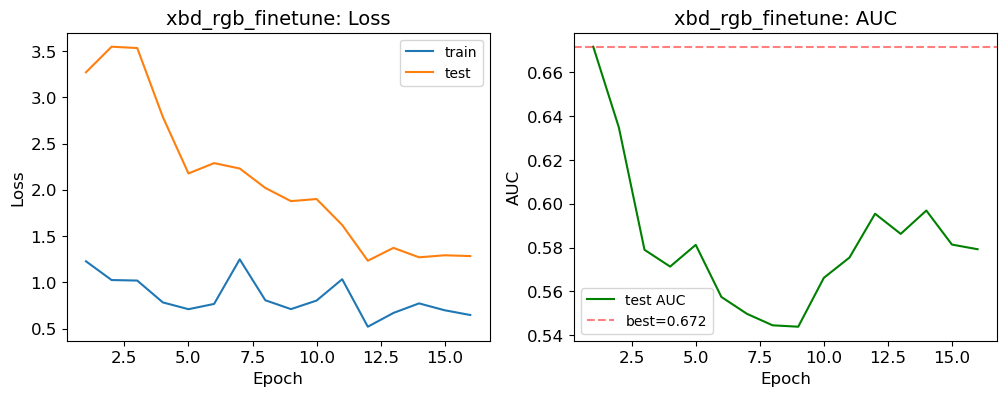

  Plot: xbd_rgb_finetune_curves_20260621_234357.png
  REG: d8b_xbd_rgb_finetune                          AUC=0.6717 F1=? n=None feat=0 cities=0 [NB09d/cell_d8]

  --- D8c: xBD ZERO-SHOT ON POST-ONLY RGB ---
  test: 15 patches (post_only, norm=/10000.0)
  D8c RESULT: zero-shot AUC=0.7027
  REG: d8c_xbd_zeroshot_rgb                          AUC=0.7027 F1=? n=None feat=0 cities=0 [NB09d/cell_d8]
    saved oof -> oof_D8c_xbd_zeroshot_rgb__20260621_232730_213609.parquet  TP=0 FN=0 FP=13 TN=2


In [24]:
# @title CELL D8: POST-ONLY RGB EXPERIMENTS
# =============================================================================
# Three experiments using post-battle RGB only (3ch) from PATCH_DIR_MS:
# 1. BDA from post-only RGB (no xBD pretrain)
# 2. xBD pretrain + post-only RGB finetune
# 3. xBD zero-shot on post-only RGB
# Uses ACTIVE_PATCH_DIR (same patches as other cells) with post_only=True
# =============================================================================
print("=" * 70)
print("CELL D8: POST-ONLY RGB EXPERIMENTS")
print("=" * 70)

if ACTIVE_MODALITY != 'ms':
    print(f"  SKIP: post-only RGB requires MS modality (active={ACTIVE_MODALITY})")
elif len(df_patches) == 0:
    print(f"  SKIP: no patches available")
else:
    print(f"  Using patches from: {ACTIVE_PATCH_DIR}")
    print(f"  Patches: {len(df_patches)}, post_only=True (3ch RGB)")

    # Experiment 1: BDA post-only RGB from scratch
    print(f"\n  --- D8a: BDA POST-ONLY RGB (from scratch) ---")
    try:
        ds_train_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                                  list(range(3)), PATCH_SPLIT, 1, post_only=True)
        ds_test_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                                 list(range(3)), PATCH_SPLIT, 1, post_only=True)
        ds_val_rgb = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'val',
                                list(range(3)), PATCH_SPLIT, 1, post_only=True)

        dl_train_rgb = DataLoader(ds_train_rgb, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        dl_test_rgb = DataLoader(ds_test_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        dl_val_rgb = DataLoader(ds_val_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        model_rgb = create_unet(in_channels=3, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS).to(DEVICE)
        optimizer_rgb = torch.optim.Adam(model_rgb.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        for epoch in range(NUM_EPOCHS_BDA):
            tl = train_epoch(model_rgb, dl_train_rgb, criterion, optimizer_rgb, DEVICE)
            vl, va = eval_epoch(model_rgb, dl_val_rgb, criterion, DEVICE)
            if (epoch+1) % 20 == 0:
                print(f"    Epoch {epoch+1}: train={tl:.4f} val_auc={va:.3f}")

        _, test_auc_rgb = eval_epoch(model_rgb, dl_test_rgb, criterion, DEVICE)
        print(f"  D8a RESULT: test_AUC={test_auc_rgb:.3f}")
        RESULTS_ALL['d8a_rgb_scratch'] = {'auc': test_auc_rgb}
        log_dl('d8a_rgb_scratch', test_auc_rgb, cell_id='cell_d8',
               note='Post-only RGB from scratch', tags=['dl', 'rgb', 'post_only', 'scratch'])
        extract_unet_oof(model_rgb, ds_test_rgb, DEVICE, 'D8a_rgb_scratch',
                         variant_id='unet_post_only;features=rgb;init=scratch')
        del model_rgb; gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"  D8a ERROR: {e}")

    # Experiment 2: xBD pretrain + post-only RGB finetune
    print(f"\n  --- D8b: xBD PRETRAIN + POST-ONLY RGB FINETUNE ---")
    if xbd_pretrain_skip:
        print("  SKIP: No xBD model")
    else:
        try:
            ft_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                                  list(range(3)), PATCH_SPLIT, 1, post_only=True)
            ft_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                                 list(range(3)), PATCH_SPLIT, 1, post_only=True)

            m = create_unet(in_channels=3, encoder_weights=None)
            m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
            m = m.to(DEVICE)
            o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best = train_model(m,
                DataLoader(ft_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
                DataLoader(ft_test, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS),
                criterion, o, s, NUM_EPOCHS_FINETUNE, DEVICE,
                MODEL_DIR / "xbd_rgb_finetune.pt", EARLY_STOP_PATIENCE)
            with open(RESULTS_DIR / "xbd_rgb_finetune_history.json", 'w') as f:
                json.dump(h, f, indent=2)
            plot_history(h, 'xbd_rgb_finetune')
            RESULTS_ALL['d8b_xbd_rgb_finetune'] = {'auc': best}
            log_dl('d8b_xbd_rgb_finetune', best, cell_id='cell_d8',
                   note='xBD pretrain + RGB post-only finetune', tags=['dl', 'rgb', 'post_only', 'finetune'])
            del m; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"  D8b ERROR: {e}")

    # Experiment 3: xBD zero-shot on post-only RGB
    print(f"\n  --- D8c: xBD ZERO-SHOT ON POST-ONLY RGB ---")
    if xbd_pretrain_skip:
        print("  SKIP: No xBD model")
    else:
        try:
            zs_ds = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                               list(range(3)), PATCH_SPLIT, 1, post_only=True)
            m = create_unet(in_channels=3, encoder_weights=None)
            m.load_state_dict(torch.load(xbd_pretrain_path, map_location=DEVICE))
            m = m.to(DEVICE)
            loss, auc = eval_epoch(m, DataLoader(zs_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS), criterion, DEVICE)
            print(f"  D8c RESULT: zero-shot AUC={auc:.4f}")
            RESULTS_ALL['d8c_xbd_zeroshot_rgb'] = {'auc': float(auc)}
            log_dl('d8c_xbd_zeroshot_rgb', float(auc), cell_id='cell_d8',
                   note='xBD zero-shot on RGB post-only', tags=['dl', 'rgb', 'post_only', 'zero_shot'])
            extract_unet_oof(m, zs_ds, DEVICE, 'D8c_xbd_zeroshot_rgb',
                             variant_id='unet_transfer;type=xbd_zero_shot;features=rgb_post_only')
            del m; gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"  D8c ERROR: {e}")


# D9: SIAMESE PRE/POST RGB (6ch concatenation)

In [25]:
# @title EXP: SIAMESE PRE/POST RGB (6ch concatenation)
EXP_ID_siam = "exp_siamese_rgb"
print("=" * 70)
print(f"EXP: SIAMESE PRE/POST RGB ({EXP_ID_siam})")
print("=" * 70)
print("Concatenates pre+post RGB (6ch) to give model temporal change signal.")
print("Tests whether pre/post comparison helps where single-image RGB fails.")
print()

# Use CHANNEL_GROUPS from Cell 10 (pre+post RGB = channels 0-5 in 6ch stack)
siam_channels = CHANNEL_GROUPS.get('ms_prepost', list(range(6)))
siam_channels_valid = len(siam_channels) == 6 and ACTIVE_MODALITY == 'ms'

if not siam_channels_valid:
    print(f"ERROR: Siamese requires MS patches with 6ch pre+post (modality={ACTIVE_MODALITY})")
else:
    print(f"Siamese channels (6ch): {siam_channels}")
    print(f"  [0-2] pre RGB (B04,B03,B02)")
    print(f"  [3-5] post RGB (B04,B03,B02)")

    siam_model_path = MODEL_DIR / f"{EXP_ID_siam}.pt"
    siam_history_path = RESULTS_DIR / f"{EXP_ID_siam}_history.json"

    if siam_model_path.exists() and not FORCE_RERUN_TRAINING:
        print(f"\nModel exists: {siam_model_path}")
        if siam_history_path.exists():
            with open(siam_history_path) as f:
                _h = json.load(f)
            print(f"Best AUC: {max(_h['test_auc']):.4f}")
    else:
        # use 20m2 masks (default, same as other experiments)
        siam_train = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train', siam_channels, PATCH_SPLIT, 1)
        siam_test = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test', siam_channels, PATCH_SPLIT, 1)

        if len(siam_train) == 0:
            print("ERROR: train dataset empty")
        else:
            print(f"\nTrain: {len(siam_train)}, Test: {len(siam_test)}, 6ch")
            siam_train_loader = DataLoader(siam_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            siam_test_loader = DataLoader(siam_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            # 6ch input -> no ImageNet weights
            siam_model = create_unet(in_channels=6, encoder_name=ENCODER_NAME)
            siam_model = siam_model.to(DEVICE)

            siam_opt = optim.AdamW(siam_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            siam_sch = optim.lr_scheduler.ReduceLROnPlateau(siam_opt, mode='min', factor=0.5, patience=5)

            siam_h, siam_best = train_model(
                siam_model, siam_train_loader, siam_test_loader, criterion, siam_opt, siam_sch,
                NUM_EPOCHS_BDA, DEVICE, siam_model_path, EARLY_STOP_PATIENCE)

            with open(siam_history_path, 'w') as f:
                json.dump(siam_h, f, indent=2)
            plot_history(siam_h, EXP_ID_siam)
            RESULTS_ALL[f'd9_{EXP_ID_siam}'] = {'auc': siam_best}
            log_dl(f'd9_{EXP_ID_siam}', siam_best, cell_id='cell_d9',
                   note='Siamese pre/post RGB (6ch)', tags=['dl', 'siamese', 'prepost'])
            print(f"\nSiamese RGB Best AUC: {siam_best:.4f}")
            del siam_model; gc.collect(); torch.cuda.empty_cache()

EXP: SIAMESE PRE/POST RGB (exp_siamese_rgb)
Concatenates pre+post RGB (6ch) to give model temporal change signal.
Tests whether pre/post comparison helps where single-image RGB fails.

Siamese channels (6ch): [0, 1, 2, 3, 4, 5]
  [0-2] pre RGB (B04,B03,B02)
  [3-5] post RGB (B04,B03,B02)

Model exists: /content/masterthesis_local/nb09d_dl_experiments/models/exp_siamese_rgb.pt
Best AUC: 0.5461


# D10: MODALITY ABLATION

In [26]:
# @title CELL D10: MODALITY ABLATION (EXPERIMENT_CONFIGS sweep)
# =============================================================================
# Iterates EXPERIMENT_CONFIGS (built in Cell 1a). Covers:
#   ms_post_rgb (3ch)     -- MS post-only RGB, ImageNet init
#   ms_prepost (6ch)      -- MS pre+post RGB, no pretrain
#   card_post (2ch)       -- CARD post-only VV/VH, no pretrain
#   card_prepost (4ch)    -- CARD pre+post VV/VH, no pretrain
#   fusion_post (5ch)     -- MS+CARD post-only, no pretrain
#   fusion_prepost (10ch) -- MS+CARD pre+post, no pretrain
# All configs train from scratch here. xBD-pretrained fusion is in D13.
# NB08b reference: BDA CARD LogReg=0.693, BDA RGB ExtraTrees=0.750, BDA RGB+CARD LogReg=0.751
# =============================================================================
print("=" * 70)
print("CELL D10: MODALITY ABLATION (from-scratch sweep)")
print("=" * 70)

if not EXPERIMENT_CONFIGS:
    print("  EXPERIMENT_CONFIGS empty (check Cell 1a)")
else:
    for config_name, cfg in EXPERIMENT_CONFIGS.items():
        n_ch = cfg['in_channels']
        print(f"\n  === {config_name} ({n_ch} channels, modality={cfg['modality']}) ===")
        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                 'test', cfg['channels'], PATCH_SPLIT, 1,
                                 normalize_range=_nr, post_only=cfg['post_only'],
                                 patch_dir_card=cfg['card_patch_dir'],
                                 card_normalize_range=_cnr)
            ds_val = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                'val', cfg['channels'], PATCH_SPLIT, 1,
                                normalize_range=_nr, post_only=cfg['post_only'],
                                patch_dir_card=cfg['card_patch_dir'],
                                card_normalize_range=_cnr)

            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"  SKIP: empty dataset (train={len(ds_train)}, test={len(ds_test)})")
                continue

            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            enc_w = ENCODER_WEIGHTS if cfg['use_imagenet'] else None
            model_mod = create_unet(in_channels=n_ch, encoder_name=ENCODER_NAME,
                                    encoder_weights=enc_w).to(DEVICE)
            optimizer_mod = torch.optim.Adam(model_mod.parameters(), lr=LEARNING_RATE,
                                             weight_decay=WEIGHT_DECAY)

            best_auc = 0
            for epoch in range(NUM_EPOCHS_BDA):
                tl = train_epoch(model_mod, dl_train, criterion, optimizer_mod, DEVICE)
                vl, va = eval_epoch(model_mod, dl_val, criterion, DEVICE)
                best_auc = max(best_auc, va)
                if (epoch + 1) % 20 == 0:
                    print(f"    Epoch {epoch+1}: train={tl:.4f} val_auc={va:.3f}")

            _, test_auc = eval_epoch(model_mod, dl_test, criterion, DEVICE)
            print(f"  RESULT: {config_name} -> test_AUC={test_auc:.3f} (best_val={best_auc:.3f})")
            RESULTS_ALL[f'd10_{config_name}'] = {'auc': test_auc, 'n_channels': n_ch,
                                                 'modality': cfg['modality'],
                                                 'n_train': len(ds_train), 'n_test': len(ds_test)}
            log_dl(f'd10_{config_name}', test_auc, cell_id='cell_d10',
                   note=f"Modality ablation: {config_name} ({n_ch}ch, {cfg['modality']})",
                   tags=['dl', 'modality_ablation', config_name, cfg['modality']])
            extract_unet_oof(model_mod, ds_test, DEVICE, f'D10_{config_name}',
                             variant_id=f'unet_modality_ablation;config={config_name};channels={n_ch};modality={cfg["modality"]}')
            del model_mod; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        except Exception as e:
            print(f"  ERROR: {e}")

# summary
print(f"\n  D10 SUMMARY:")
for k in sorted(k for k in RESULTS_ALL if k.startswith('d10_')):
    v = RESULTS_ALL[k]
    print(f"    {k:30s} AUC={v.get('auc', 0):.3f} ({v.get('n_channels','?')}ch {v.get('modality','?')})")


CELL D10: MODALITY ABLATION (from-scratch sweep)

  === ms_post_rgb (3 channels, modality=ms) ===
  train: 49 patches (post_only, norm=/10000.0)
  test: 15 patches (post_only, norm=/10000.0)
  val: 12 patches (post_only, norm=/10000.0)
    Epoch 20: train=0.5638 val_auc=0.538
    Epoch 40: train=0.3983 val_auc=0.632
    Epoch 60: train=0.2545 val_auc=0.611
    Epoch 80: train=0.2120 val_auc=0.566
    Epoch 100: train=0.2267 val_auc=0.666
  RESULT: ms_post_rgb -> test_AUC=0.449 (best_val=0.676)
  REG: d10_ms_post_rgb                               AUC=0.4491 F1=? n=None feat=0 cities=0 [NB09d/cell_d10]
    saved oof -> oof_D10_ms_post_rgb__20260621_232730_213609.parquet  TP=0 FN=0 FP=0 TN=15

  === ms_prepost (6 channels, modality=ms) ===
  train: 49 patches (pre+post, norm=/10000.0)
  test: 15 patches (pre+post, norm=/10000.0)
  val: 12 patches (pre+post, norm=/10000.0)
    Epoch 20: train=0.6760 val_auc=0.476
    Epoch 40: train=0.4296 val_auc=0.543
    Epoch 60: train=0.3062 val_auc=0

# D11: ATTENTION U-NET (SE-ResNeXt + scSE)

In [27]:
# @title CELL 6f: ARCHITECTURE COMPARISON
print("=" * 70)
print("CELL 6f: ARCHITECTURE COMPARISON")
print("=" * 70)

# create post-only RGB loaders inline
_arch_skip = ACTIVE_MODALITY != 'ms' or len(df_patches) == 0
if _arch_skip:
    print("  SKIP: requires MS patches")
    bda_tr, bda_te = None, None
else:
    _ds_tr = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'train',
                        CHANNEL_GROUPS.get('ms_post_rgb', list(range(3))), PATCH_SPLIT, 1, post_only=True)
    _ds_te = BDADataset(ACTIVE_PATCH_DIR, MASK_DIR, df_patches, 'test',
                        CHANNEL_GROUPS.get('ms_post_rgb', list(range(3))), PATCH_SPLIT, 1, post_only=True)
    bda_tr = DataLoader(_ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    bda_te = DataLoader(_ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
if bda_tr is None or len(bda_tr) == 0:
    print("  No BDA patches. Run Cell 1a-1d first.")
else:
    arch_results = {}
    architectures = {
        'resnet34':        {'encoder': 'resnet34',        'attention': None,   'note': 'baseline'},
        'resnet50':        {'encoder': 'resnet50',        'attention': None,   'note': 'deeper encoder'},
        'efficientnet-b0': {'encoder': 'efficientnet-b0', 'attention': None,   'note': 'param efficient'},
        'resnet34+scse':   {'encoder': 'resnet34',        'attention': 'scse', 'note': 'spatial+channel SE'},
        'resnet50+scse':   {'encoder': 'resnet50',        'attention': 'scse', 'note': 'deeper + attention'},
    }

    for arch_name, cfg in architectures.items():
        print(f"\n  --- {arch_name} ({cfg['note']}) ---")
        t0 = time.time()
        try:
            model_arch = smp.Unet(encoder_name=cfg['encoder'], encoder_weights='imagenet',
                                   in_channels=3, classes=1, decoder_attention_type=cfg['attention'])
            model_arch = model_arch.to(DEVICE)
            n_params = sum(p.numel() for p in model_arch.parameters())
            print(f"    Parameters: {n_params/1e6:.1f}M")

            arch_model_path = MODEL_DIR / f"arch_{arch_name.replace('+','_')}.pt"
            o = optim.AdamW(model_arch.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best_auc = train_model(model_arch, bda_tr, bda_te, criterion, o, s,
                                       NUM_EPOCHS_BDA, DEVICE, arch_model_path, EARLY_STOP_PATIENCE)
            elapsed = time.time() - t0
            arch_results[arch_name] = {
                'auc': best_auc, 'n_params_M': n_params / 1e6,
                'time_min': elapsed / 60, 'note': cfg['note'],
            }
            RESULTS_ALL[f'd11_{arch_name}'] = {'auc': best_auc}
            log_dl(f'd11_{arch_name}', best_auc, cell_id='cell_d11',
                   note=f'Architecture comparison: {arch_name}',
                   tags=['dl', 'architecture', arch_name])
            print(f"    AUC={best_auc:.3f}, Time={elapsed/60:.1f}min")
            plot_history(h, f'arch_{arch_name}')
            del model_arch; torch.cuda.empty_cache()
        except Exception as e:
            print(f"    FAILED: {e}")
            arch_results[arch_name] = {'auc': 0, 'note': f'FAILED: {e}'}

    # summary
    print(f"\n{'='*75}")
    print(f"  ARCHITECTURE COMPARISON SUMMARY")
    print(f"{'='*75}")
    print(f"  {'Architecture':25s} {'AUC':>7s} {'Params':>8s} {'Time':>8s} {'Note'}")
    for name, r in sorted(arch_results.items(), key=lambda x: -x[1].get('auc', 0)):
        print(f"  {name:25s} {r.get('auc',0):7.3f} {r.get('n_params_M',0):7.1f}M {r.get('time_min',0):7.1f}m {r.get('note','')}")

    if arch_results:
        arch_df = pd.DataFrame([{'architecture': k, **v} for k, v in arch_results.items()])
        save_result(arch_df, 'architecture_comparison', 'cell_d11')


CELL 6f: ARCHITECTURE COMPARISON
  train: 49 patches (post_only, norm=/10000.0)
  test: 15 patches (post_only, norm=/10000.0)

  --- resnet34 (baseline) ---
    Parameters: 24.4M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet50 (deeper encoder) ---
    Parameters: 32.5M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- efficientnet-b0 (param efficient) ---
    Parameters: 6.3M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet34+scse (spatial+channel SE) ---
    Parameters: 24.6M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  --- resnet50+scse (deeper + attention) ---
    Parameters: 33.8M
    FAILED: index 3 is out of bounds for axis 0 with size 3

  ARCHITECTURE COMPARISON SUMMARY
  Architecture                  AUC   Params     Time Note
  resnet34                    0.000     0.0M     0.0m FAILED: index 3 is out of bounds for axis 0 with size 3
  resnet50                    0.000     0.0M     0.0m FA

# D13: xBD-PRETRAINED FUSION (MS+CARD)

Key iteration-C experiment. Builds a multimodal U-Net where the RGB channels of
the first conv receive xBD pretrained weights (via first-conv surgery), while
CARD channels are randomly initialised. Rest of encoder + decoder fully inherits
xBD weights. Then finetuned on BDA fusion patches.

Rationale (NB08b findings):
- BDA RGB pixel features have Cohen's d ~ 0 (no pixel-level signal at 10m)
- BDA CARD features have Cohen's d 0.3-0.6 (real pixel-level signal)
- xBD-pretrained RGB zero-shot transfers to BDA with AUC=0.70
- xBD pretraining carries useful texture priors; CARD adds the signal that RGB lacks

Experiments:
- D13a: xBD pretrain -> fusion_post (5ch) finetune
- D13b: xBD pretrain -> fusion_prepost (10ch) finetune


In [28]:
# @title CELL D13: xBD-PRETRAINED FUSION EXPERIMENTS
# =============================================================================
# xBD-pretrained fusion U-Net: RGB channels init from xBD, CARD channels random.
# Uses create_fusion_unet_from_xbd() (Cell 0d).
# =============================================================================
print("=" * 70)
print("CELL D13: xBD-PRETRAINED FUSION (MS+CARD)")
print("=" * 70)

if not FUSION_AVAILABLE:
    print("  SKIP: fusion requires both MS and CARD patches (check Cell 1a)")
elif xbd_pretrain_skip:
    print("  SKIP: no xBD pretrained model available")
else:
    # rgb_indices per fusion stack (see BDADataset docstring)
    #   fusion_post  5ch: RGB_post [0,1,2] then CARD_post [3,4]
    #   fusion_prepost 10ch: RGB_pre [0,1,2] + RGB_post [3,4,5] + CARD_pre [6,7] + CARD_post [8,9]
    D13_EXPERIMENTS = {
        'd13a_fusion_post_xbd': dict(
            config_name='fusion_post', rgb_indices=[0, 1, 2]),
        'd13b_fusion_prepost_xbd': dict(
            config_name='fusion_prepost', rgb_indices=[0, 1, 2, 3, 4, 5]),
    }

    for exp_name, spec in D13_EXPERIMENTS.items():
        cfg = EXPERIMENT_CONFIGS.get(spec['config_name'])
        if cfg is None:
            print(f"\n  SKIP {exp_name}: EXPERIMENT_CONFIGS['{spec['config_name']}'] missing")
            continue
        n_ch = cfg['in_channels']
        print(f"\n  === {exp_name} ({n_ch}ch, rgb_indices={spec['rgb_indices']}) ===")

        fm_path = MODEL_DIR / f"{exp_name}.pt"
        fh_path = RESULTS_DIR / f"{exp_name}_history.json"
        if fm_path.exists() and not FORCE_RERUN_TRAINING:
            if fh_path.exists():
                with open(fh_path) as f: _h = json.load(f)
                best = max(_h['test_auc'])
                print(f"  Cached: best AUC={best:.4f}")
                RESULTS_ALL[exp_name] = {'auc': best, 'n_channels': n_ch, 'modality': 'fusion_xbd'}
                log_dl(exp_name, best, cell_id='cell_d13',
                       note=f'xBD-pretrained fusion (cached): {spec["config_name"]}',
                       tags=['dl', 'fusion', 'xbd_pretrain', spec['config_name'], 'cached'])
            continue

        try:
            _nr = cfg.get('normalize_range', 10000.0)
            _cnr = cfg.get('card_normalize_range')
            ds_train = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                  'train', cfg['channels'], PATCH_SPLIT, 1,
                                  normalize_range=_nr, post_only=cfg['post_only'],
                                  patch_dir_card=cfg['card_patch_dir'],
                                  card_normalize_range=_cnr)
            ds_test = BDADataset(cfg['primary_patch_dir'], cfg['mask_dir'], cfg['df_patches'],
                                 'test', cfg['channels'], PATCH_SPLIT, 1,
                                 normalize_range=_nr, post_only=cfg['post_only'],
                                 patch_dir_card=cfg['card_patch_dir'],
                                 card_normalize_range=_cnr)
            if len(ds_train) == 0 or len(ds_test) == 0:
                print(f"  SKIP: empty dataset (train={len(ds_train)}, test={len(ds_test)})")
                continue

            dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
            dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

            m = create_fusion_unet_from_xbd(
                xbd_weights_path=xbd_pretrain_path,
                in_channels=n_ch,
                rgb_indices=spec['rgb_indices'],
                encoder_name=ENCODER_NAME,
            ).to(DEVICE)
            # lower LR for finetune (matches D5b)
            o = optim.AdamW(m.parameters(), lr=LEARNING_RATE * 0.1, weight_decay=WEIGHT_DECAY)
            s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=5)
            h, best = train_model(m, dl_train, dl_test, criterion, o, s,
                                  NUM_EPOCHS_FINETUNE, DEVICE, fm_path, EARLY_STOP_PATIENCE)
            with open(fh_path, 'w') as f:
                json.dump(h, f, indent=2)
            plot_history(h, exp_name)
            RESULTS_ALL[exp_name] = {'auc': best, 'n_channels': n_ch, 'modality': 'fusion_xbd',
                                     'n_train': len(ds_train), 'n_test': len(ds_test)}
            log_dl(exp_name, best, cell_id='cell_d13',
                   note=f'xBD-pretrained fusion finetune: {spec["config_name"]}',
                   tags=['dl', 'fusion', 'xbd_pretrain', spec['config_name']])
            del m; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        except Exception as e:
            print(f"  ERROR: {e}")

# summary
print(f"\n  D13 SUMMARY:")
for k in sorted(k for k in RESULTS_ALL if k.startswith('d13')):
    v = RESULTS_ALL[k]
    print(f"    {k:35s} AUC={v.get('auc', 0):.3f} ({v.get('n_channels','?')}ch)")


CELL D13: xBD-PRETRAINED FUSION (MS+CARD)

  === d13a_fusion_post_xbd (5ch, rgb_indices=[0, 1, 2]) ===
  Cached: best AUC=0.5112
  REG: d13a_fusion_post_xbd                          AUC=0.5112 F1=? n=None feat=0 cities=0 [NB09d/cell_d13]

  === d13b_fusion_prepost_xbd (10ch, rgb_indices=[0, 1, 2, 3, 4, 5]) ===
  Cached: best AUC=0.5245
  REG: d13b_fusion_prepost_xbd                       AUC=0.5245 F1=? n=None feat=0 cities=0 [NB09d/cell_d13]

  D13 SUMMARY:
    d13a_fusion_post_xbd                AUC=0.511 (5ch)
    d13b_fusion_prepost_xbd             AUC=0.525 (10ch)


# D12: RESULTS SUMMARY + SAVE

CELL D12: RESULTS SUMMARY

  Experiment                                     AUC  Note
  ------------------------------------------ -------  ----------------------------------------
  Dietrich_2025_RF                             0.813  Dietrich 2025 RF (paper ref)
  xBD_on_xBD                                   0.876  xBD-on-xBD U-Net (DL clean-sup ceiling)
  NB08b_BDA_RGB_ExtraTrees                     0.750  NB08b: BDA single-scene RGB, ExtraTrees (area_px-driven)
  NB08b_BDA_CARD_LogReg                        0.693  NB08b: BDA single-scene CARD, LogReg
  NB08b_BDA_RGB_CARD_LogReg                    0.751  NB08b: BDA RGB+CARD tabular fusion, LogReg
  NB08b_BDA_COHDROP_RGB_CARD                   0.748  NB08b: BDA COH_DROP+RGB+CARD, LogReg
  ------------------------------------------ -------  ----------------------------------------
  bda_min100                                   0.517  
  bda_min20                                    0.436  
  bda_min200                                   

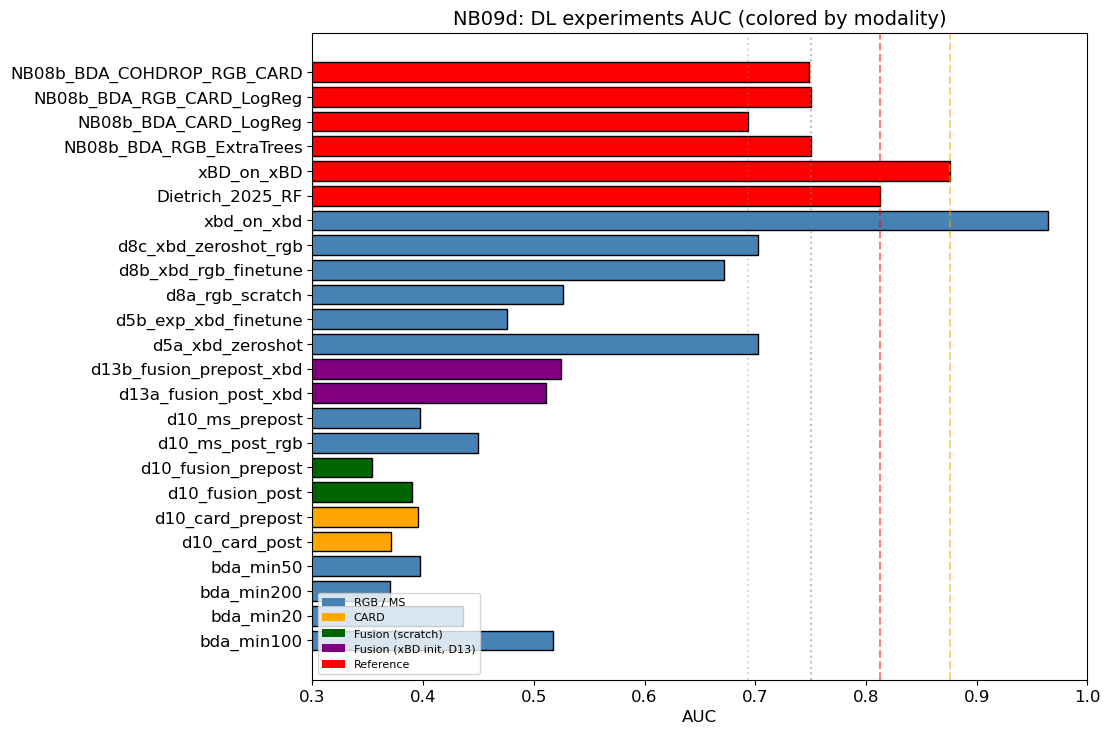

  Plot: dl_experiments_auc_20260621_235931.png

  BEST PER MODALITY:
    card           : d10_card_prepost                    AUC=0.395
    fusion         : d10_fusion_post                     AUC=0.390
    fusion_xbd     : d13b_fusion_prepost_xbd             AUC=0.525
    ms             : d10_ms_post_rgb                     AUC=0.449
    unknown        : xbd_on_xbd                          AUC=0.964


In [29]:
# @title CELL D12: RESULTS SUMMARY + SAVE
import json

print("=" * 70)
print("CELL D12: RESULTS SUMMARY")
print("=" * 70)

# references (paper + this-thesis tabular baselines from NB08b)
REFERENCES = {
    'Dietrich_2025_RF':            {'auc': 0.813, 'note': 'Dietrich 2025 RF (paper ref)',          'color': 'red'},
    'xBD_on_xBD':                  {'auc': 0.876, 'note': 'xBD-on-xBD U-Net (DL clean-sup ceiling)', 'color': 'orange'},
    'NB08b_BDA_RGB_ExtraTrees':    {'auc': 0.7503,'note': 'NB08b: BDA single-scene RGB, ExtraTrees (area_px-driven)', 'color': 'gray'},
    'NB08b_BDA_CARD_LogReg':       {'auc': 0.6932,'note': 'NB08b: BDA single-scene CARD, LogReg',  'color': 'gray'},
    'NB08b_BDA_RGB_CARD_LogReg':   {'auc': 0.7506,'note': 'NB08b: BDA RGB+CARD tabular fusion, LogReg', 'color': 'gray'},
    'NB08b_BDA_COHDROP_RGB_CARD':  {'auc': 0.7483,'note': 'NB08b: BDA COH_DROP+RGB+CARD, LogReg',  'color': 'gray'},
}

# ---- printed table ----
print(f"\n  {'Experiment':<42s} {'AUC':>7s}  {'Note'}")
print(f"  {'-'*42} {'-'*7}  {'-'*40}")
for key, ref in REFERENCES.items():
    print(f"  {key:<42s} {ref['auc']:>7.3f}  {ref['note']}")
print(f"  {'-'*42} {'-'*7}  {'-'*40}")
for key in sorted(RESULTS_ALL.keys()):
    auc = RESULTS_ALL[key].get('auc', 0)
    mod = RESULTS_ALL[key].get('modality', '')
    nch = RESULTS_ALL[key].get('n_channels', '')
    extra = f'{mod} {nch}ch' if mod else ''
    print(f"  {key:<42s} {auc:>7.3f}  {extra}")

# ---- save json + csv ----
serializable = {k: {kk: float(vv) if isinstance(vv, (int, float)) else str(vv)
                    for kk, vv in v.items()}
                for k, v in RESULTS_ALL.items()}
save_result(serializable, 'nb09d_results', 'cell_d12', fmt='json')

summary_rows = [{'experiment': k, 'auc': v.get('auc', 0),
                 'modality': v.get('modality', ''),
                 'n_channels': v.get('n_channels', '')}
                for k, v in sorted(RESULTS_ALL.items())]
for rk, rv in REFERENCES.items():
    summary_rows.append({'experiment': rk, 'auc': rv['auc'], 'modality': 'reference', 'n_channels': ''})
if summary_rows:
    save_result(pd.DataFrame(summary_rows), 'experiment_summary', 'cell_d12')

# ---- OOF predictions inventory (for NB12 overlap analysis) ----
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09d_oof_inventory', 'cell_d12')
    print(f"  Total OOF parquets: {len(oof_files)}")
else:
    print(f"  No OOF parquets saved")

# ---- registry ----
# note: log_reference / log_experiment signature mismatch in bda_results.py can raise
# TypeError here. Keep going so the bar chart + summary below still render.
_refs_to_log = [
    ('Dietrich_2025',                       {'auc': 0.813, 'f1': 0.749,
        'paper': 'Dietrich et al. 2025', 'note': 'RF on S1, geographic split'}),
    ('xBD_on_xBD_reference',                {'auc': 0.876,
        'paper': 'this_thesis', 'note': 'xBD pretrain+eval on xBD val (VALID)'}),
    ('NB08b_BDA_RGB_ExtraTrees',            {'auc': 0.7503,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA single-scene RGB, ExtraTrees, 21 cities, GroupKFold (area_px-driven)'}),
    ('NB08b_BDA_CARD_LogReg',               {'auc': 0.6932,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA single-scene CARD (VV/VH), LogReg, 21 cities'}),
    ('NB08b_BDA_RGB_CARD_LogReg',           {'auc': 0.7506,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA RGB+CARD tabular fusion, LogReg, 21 cities'}),
    ('NB08b_BDA_COHDROP_RGB_CARD_LogReg',   {'auc': 0.7483,
        'paper': 'this_thesis_nb08b',
        'note': 'BDA COH_DROP+RGB+CARD, LogReg, 12 cities (COH-available)'}),
]
_registry_errors = 0
for _name, _kw in _refs_to_log:
    try:
        registry.log_reference(_name, **_kw)
    except TypeError as _e:
        _registry_errors += 1
        if _registry_errors == 1:
            print(f"  WARN: registry.log_reference failed ({_e}). Skipping registry refs.")
try:
    registry.save()
except Exception as _e:
    print(f"  WARN: registry.save failed: {_e}")

# ---- bar chart: color by modality ----
def _modality_color(key, default='steelblue'):
    if 'reference' in key.lower() or key in REFERENCES:
        return 'red'
    if key.startswith('d13'): return 'purple'          # xBD fusion
    k_lo = key.lower()
    if 'fusion' in k_lo: return 'darkgreen'             # fusion from scratch
    if 'card' in k_lo: return 'orange'                  # CARD
    if 'rgb' in k_lo or 'xbd' in k_lo or 'siamese' in k_lo or k_lo.startswith('bda_min'):
        return 'steelblue'                              # RGB/MS variants
    return default

if RESULTS_ALL or REFERENCES:
    import matplotlib.pyplot as plt
    all_rows = []
    for k, v in sorted(RESULTS_ALL.items()):
        all_rows.append({'experiment': k, 'auc': v.get('auc', 0)})
    for rk, rv in REFERENCES.items():
        all_rows.append({'experiment': rk, 'auc': rv['auc']})
    labels = [r['experiment'] for r in all_rows]
    aucs = [r['auc'] for r in all_rows]
    colors = [_modality_color(l) for l in labels]
    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.35)))
    ax.barh(labels, aucs, color=colors, edgecolor='black')
    ax.set_xlabel('AUC')
    ax.set_xlim(0.3, 1.0)
    ax.axvline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich=0.813')
    ax.axvline(0.876, color='orange', linestyle='--', alpha=0.5, label='xBD-on-xBD=0.876')
    ax.axvline(0.7503, color='gray', linestyle=':', alpha=0.5, label='NB08b BDA RGB tab=0.750')
    ax.axvline(0.6932, color='gray', linestyle=':', alpha=0.3, label='NB08b BDA CARD tab=0.693')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_title('NB09d: DL experiments AUC (colored by modality)')
    # legend for modalities
    from matplotlib.patches import Patch
    mod_legend = [
        Patch(facecolor='steelblue', label='RGB / MS'),
        Patch(facecolor='orange',    label='CARD'),
        Patch(facecolor='darkgreen', label='Fusion (scratch)'),
        Patch(facecolor='purple',    label='Fusion (xBD init, D13)'),
        Patch(facecolor='red',       label='Reference'),
    ]
    ax.legend(handles=mod_legend, fontsize=8, loc='lower left')
    save_fig(fig, 'dl_experiments_auc', 'cell_d12')

# ---- best-per-modality ----
print(f"\n  BEST PER MODALITY:")
by_mod = {}
for k, v in RESULTS_ALL.items():
    mod = v.get('modality', 'unknown')
    auc = v.get('auc', 0)
    if mod not in by_mod or auc > by_mod[mod][1]:
        by_mod[mod] = (k, auc)
for mod, (k, auc) in sorted(by_mod.items()):
    print(f"    {mod:15s}: {k:35s} AUC={auc:.3f}")


missing ? save experiments and models
save results, mean vs pooled
analyze TP TN FPFN , analyse spatial patterns
compare to ML methods